# Argentina Election Pipeline

End-to-end daily pipeline: Argentine stock market and election prediction-market integration, factor-model residualisation, predictive model comparison, scenario simulation, CVaR risk diagnostics, and hedge sizing.

**Run order:** Execute all cells top to bottom. Each section depends only on outputs from sections above it.

## 1) Market and Election Data Inputs

Download Argentine stock index (^MERV) and South American proxy ETFs via yfinance. Load the LLA (La Libertad Avanza) election prediction-market series from the local `Argentina.csv`. Add the final resolution point at 2025-11-19.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# =========================
# Import Argentine + South America proxy data
# =========================
start = pd.Timestamp("2025-01-01").date()
end = pd.Timestamp("2026-01-01").date()

def fetch_one(symbols, start, end):
    """Try a list of symbols; return the first non-empty Close series (tz-naive)."""
    for s in symbols:
        try:
            df = yf.download(s, start=start, end=end, auto_adjust=True, progress=False, threads=False)
            if isinstance(df, pd.DataFrame) and "Close" in df and not df["Close"].dropna().empty:
                sr = df["Close"].dropna().copy()
                sr.index = pd.to_datetime(sr.index).tz_localize(None)
                sr.name = s
                return sr
        except Exception:
            pass
    return pd.Series(dtype=float)

# Download Argentine stock index (target series)
merval_ars = fetch_one(["^MERV", "M.BA"], start, end)
merval_ars.name = "^MERV"

# Download tradable South America proxy ETFs (excluding Argentina proxies)
proxy_symbols = ["ILF", "EWZ", "ECH", "EPU", "GXG"]
proxy_series = []
for symbol in proxy_symbols:
    series = fetch_one([symbol], start, end)
    series.name = symbol
    proxy_series.append(series)

proxy_df = pd.concat(proxy_series, axis=1) if proxy_series else pd.DataFrame()

# Assemble prices
df_px = pd.concat([merval_ars, proxy_df], axis=1).dropna(how="all")

print("Argentine + South America proxy stock data:")
display(df_px)

Argentine + South America proxy stock data:


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_51829/1773583594.py:41: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_px = pd.concat([merval_ars, proxy_df], axis=1).dropna(how="all")


Ticker,^MERV,ILF,EWZ,ECH,EPU,GXG
Date,,,,,,
2025-01-02,2695646.0,20.148132,21.539618,24.160854,39.057720,21.547491
2025-01-03,2728911.0,19.909636,21.293020,23.956018,38.969753,21.679941
2025-01-06,2801221.0,20.262609,21.662918,24.297411,39.360722,21.510468
2025-01-07,2822175.0,20.491564,21.985397,24.521755,39.057720,22.075071
2025-01-08,2782477.0,20.338928,21.691374,24.541264,39.409592,22.075071
...,...,...,...,...,...,...
2025-12-24,3121145.0,30.577951,31.443562,39.952232,72.739998,36.575344
2025-12-26,3112380.0,30.726967,31.622955,40.211731,73.769997,36.546768
2025-12-29,3100075.0,30.419001,31.314001,40.072002,71.949997,36.661068


In [2]:
from pathlib import Path
import pandas as pd

csv_path = Path("Argentina.csv")
argentina_csv = pd.read_csv(csv_path)

display(argentina_csv.head())

,category,PRO (Propuesta Republicana),UP (Unión por la Patria),LLA (La Libertad Avanza),UCR (Unión Cívica Radical),HNP (Hacemos por Nuestro País),FIT-U (Frente de Izquierda y de los Trabajadores – Unidad),SER (SER Santa Cruz)
0,Thu Feb 06 2025,0.021,0.24,0.72,0.010,0.010,0.010,0.010
1,Fri Feb 07 2025,0.011,0.22,0.76,0.004,0.003,0.003,0.006
2,Sat Feb 08 2025,0.012,0.22,0.73,0.008,0.019,0.006,0.001
3,Sun Feb 09 2025,0.013,0.23,0.72,0.010,0.008,0.008,0.020
4,Mon Feb 10 2025,0.013,0.22,0.72,0.010,0.008,0.008,0.013


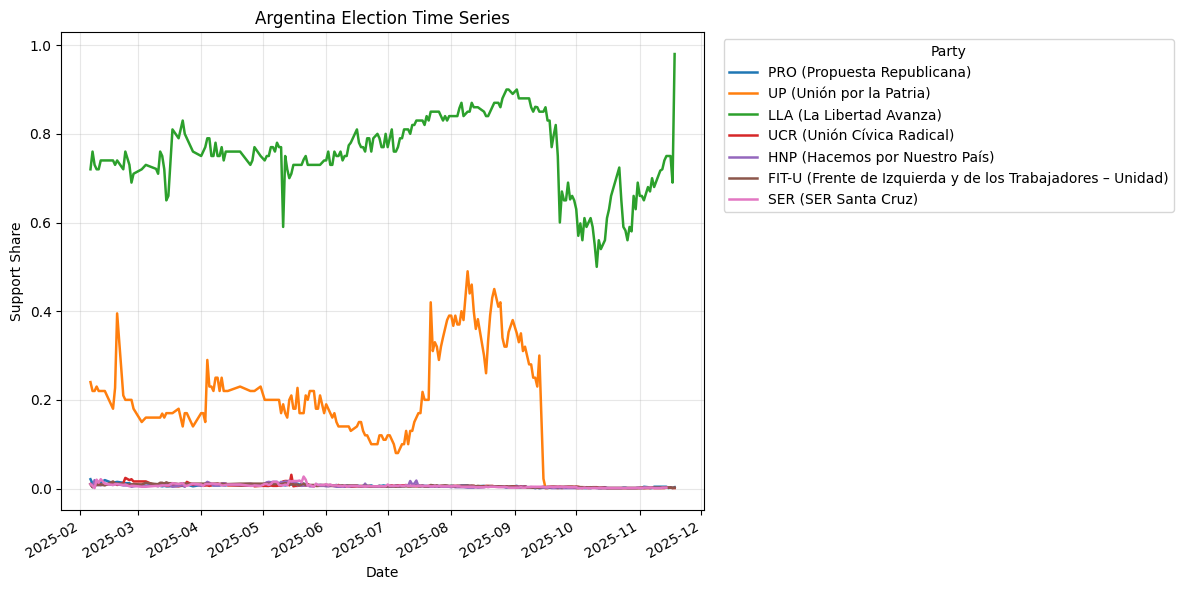

In [3]:
# Prepare and plot election time series
election_ts = argentina_csv.copy()
election_ts["category"] = pd.to_datetime(election_ts["category"], errors="coerce")
election_ts = election_ts.dropna(subset=["category"]).sort_values("category").set_index("category")

party_cols = election_ts.select_dtypes(include="number").columns

ax = election_ts[party_cols].plot(figsize=(12, 6), linewidth=1.8)
ax.set_title("Argentina Election Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Support Share")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Isolate the LLA column as its own DataFrame
lla_ts = election_ts[["LLA (La Libertad Avanza)"]].copy()

display(lla_ts.tail())

# the last point in the series is .98 as the election results came in. This indicates that LLA won the most seats. It did not resolve at 1 but this is likely due to the series not recording the 1 entry at resolution. We can simply add a 1 at the end.

,LLA (La Libertad Avanza)
category,
2025-11-14,0.75
2025-11-15,0.75
2025-11-16,0.75
2025-11-17,0.69
2025-11-18,0.98


In [5]:
# Add the resolution point for LLA at 2025-11-19
lla_ts.loc[pd.Timestamp("2025-11-19"), "LLA (La Libertad Avanza)"] = 1.0
lla_ts = lla_ts.sort_index()

display(lla_ts.tail())

,LLA (La Libertad Avanza)
category,
2025-11-15,0.75
2025-11-16,0.75
2025-11-17,0.69
2025-11-18,0.98
2025-11-19,1.00


In [6]:
# Inner join stock prices with LLA series on date index
stock_lla = df_px.copy()
stock_lla.index = pd.to_datetime(stock_lla.index).normalize()

lla_only = lla_ts.copy()
lla_only.index = pd.to_datetime(lla_only.index).normalize()

merged_inner = stock_lla.join(lla_only, how="inner")

display(merged_inner.head())
print("Merged shape:", merged_inner.shape)

,^MERV,ILF,EWZ,ECH,EPU,GXG,LLA (La Libertad Avanza)
Date,,,,,,,
2025-02-06,2503483.0,22.523550,24.441919,27.535767,41.110302,24.222416,0.72
2025-02-07,2416382.0,22.285053,23.920263,27.545521,40.914818,24.240929,0.76
2025-02-10,2391368.0,22.485392,24.261709,27.594294,41.452400,24.305719,0.72
2025-02-11,2273568.0,22.618946,24.460890,27.613798,40.367462,24.389019,0.74
2025-02-13,2353744.0,22.494928,24.147896,28.423388,41.227596,24.379765,0.74


Merged shape: (169, 7)


## 2) Data Alignment and Feature Construction

Align stock prices with the LLA series on a common daily date index. Apply linear interpolation inside observed gaps before computing returns — this avoids the volatility downward-bias from zero-filled returns. Construct MERV returns, proxy ETF returns, and LLA returns. NaN investigation confirms the interpolation reduces missing values materially.

In [7]:
# Calculate daily simple returns (percentage change)
proxy_symbols = ["ILF", "EWZ", "ECH", "EPU", "GXG"]

# Linear interpolation on market price series (inside gaps only) before return calculation
price_cols = ['^MERV'] + [s for s in proxy_symbols if s in merged_inner.columns]
price_cols = [c for c in price_cols if c in merged_inner.columns]
if price_cols:
    merged_inner[price_cols] = merged_inner[price_cols].interpolate(
        method='linear', limit_area='inside'
    )

merged_inner['MERV_returns'] = merged_inner['^MERV'].pct_change()
for symbol in proxy_symbols:
    if symbol in merged_inner.columns:
        merged_inner[f'{symbol}_returns'] = merged_inner[symbol].pct_change()
merged_inner['LLA_returns'] = merged_inner['LLA (La Libertad Avanza)'].pct_change()

preview_cols = ['^MERV', 'LLA (La Libertad Avanza)', 'MERV_returns', 'LLA_returns']
preview_cols += [c for c in [f'{s}_returns' for s in proxy_symbols] if c in merged_inner.columns]

display(merged_inner[preview_cols].head(10))

,^MERV,LLA (La Libertad Avanza),MERV_returns,LLA_returns,ILF_returns,EWZ_returns,ECH_returns,EPU_returns,GXG_returns
Date,,,,,,,,,
2025-02-06,2503483.0,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-07,2416382.0,0.76,-0.034792,0.055556,-0.010589,-0.021343,0.000354,-0.004755,0.000764
2025-02-10,2391368.0,0.72,-0.010352,-0.052632,0.008990,0.014274,0.001771,0.013139,0.002673
2025-02-11,2273568.0,0.74,-0.049261,0.027778,0.005940,0.008210,0.000707,-0.026173,0.003427
2025-02-13,2353744.0,0.74,0.035264,0.000000,-0.005483,-0.012796,0.029318,0.021308,-0.000379
2025-02-17,2254189.0,0.74,-0.042296,0.000000,0.014207,0.018264,-0.012354,-0.001897,0.013478
2025-02-18,2391725.0,0.73,0.061014,-0.013514,0.014008,0.017936,-0.012509,-0.001900,0.013298
2025-02-19,2401580.0,0.74,0.004120,0.013699,-0.011546,-0.011368,0.006334,-0.007853,0.016266
2025-02-25,2282899.0,0.73,-0.049418,-0.013514,-0.028786,-0.031046,0.011538,-0.016551,0.013459


NaN percentage by return column: pre vs post interpolation


,NaN % (pre),NaN % (post),Reduction (pp)
MERV_returns,10.059172,0.591716,9.467456
GXG_returns,6.508876,0.591716,5.917160
ILF_returns,5.325444,0.591716,4.733728
ECH_returns,5.325444,0.591716,4.733728
EWZ_returns,5.325444,0.591716,4.733728
EPU_returns,5.325444,0.591716,4.733728
LLA_returns,0.591716,0.591716,0.000000



NaN distribution by day of week: pre vs post interpolation


,NaN_count_pre,NaN_count_post,NaN_pct_pre,NaN_pct_post
day_of_week,,,,
Monday,10,0,30.30,0.00
Tuesday,4,0,11.76,0.00
Wednesday,3,0,8.57,0.00
Thursday,4,1,11.76,2.94
Friday,5,0,15.15,0.00


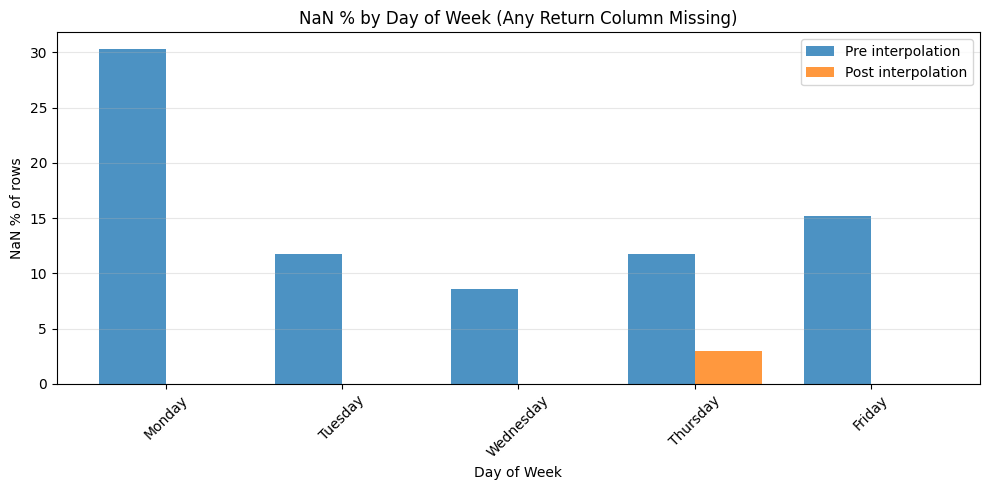

In [8]:
# ====================================================
# Investigate NaN patterns: pre vs post interpolation
# ====================================================

proxy_symbols = ["ILF", "EWZ", "ECH", "EPU", "GXG"]
proxy_price_cols = [s for s in proxy_symbols if s in df_px.columns]
price_cols = [c for c in ['^MERV'] + proxy_price_cols if c in df_px.columns]
proxy_ret_cols = [f"{s}_returns" for s in proxy_price_cols]

# Rebuild aligned panel from prices + LLA (without mutating merged_inner)
stock_lla_diag = df_px.copy()
stock_lla_diag.index = pd.to_datetime(stock_lla_diag.index).normalize()
lla_only_diag = lla_ts.copy()
lla_only_diag.index = pd.to_datetime(lla_only_diag.index).normalize()
base_df = stock_lla_diag.join(lla_only_diag, how="inner")

# ---------- Returns without interpolation ----------
raw_df = base_df.copy()
raw_df['MERV_returns'] = raw_df['^MERV'].pct_change()
for symbol in proxy_price_cols:
    raw_df[f'{symbol}_returns'] = raw_df[symbol].pct_change()
raw_df['LLA_returns'] = raw_df['LLA (La Libertad Avanza)'].pct_change()

# ---------- Returns with linear interpolation on market prices ----------
interp_df = base_df.copy()
if price_cols:
    interp_df[price_cols] = interp_df[price_cols].interpolate(
        method='linear', limit_area='inside'
    )
interp_df['MERV_returns'] = interp_df['^MERV'].pct_change()
for symbol in proxy_price_cols:
    interp_df[f'{symbol}_returns'] = interp_df[symbol].pct_change()
interp_df['LLA_returns'] = interp_df['LLA (La Libertad Avanza)'].pct_change()

# Columns to assess
return_cols = ['MERV_returns', 'LLA_returns'] + proxy_ret_cols
return_cols = [c for c in return_cols if c in raw_df.columns and c in interp_df.columns]

# Column-level NaN percentage comparison
pre_nan_pct = (raw_df[return_cols].isna().mean() * 100).rename('NaN % (pre)')
post_nan_pct = (interp_df[return_cols].isna().mean() * 100).rename('NaN % (post)')
nan_compare = pd.concat([pre_nan_pct, post_nan_pct], axis=1)
nan_compare['Reduction (pp)'] = nan_compare['NaN % (pre)'] - nan_compare['NaN % (post)']

print('NaN percentage by return column: pre vs post interpolation')
display(nan_compare.sort_values('NaN % (pre)', ascending=False))
print()

# Day-of-week NaN comparison (any missing return in row)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pre_dow = pd.DataFrame(index=raw_df.index)
pre_dow['day_of_week'] = raw_df.index.day_name()
pre_dow['is_nan'] = raw_df[return_cols].isna().any(axis=1).astype(int)
pre_dow = pre_dow.groupby('day_of_week')['is_nan'].agg(['sum', 'count'])
pre_dow.columns = ['NaN_count_pre', 'Total_count']
pre_dow['NaN_pct_pre'] = (pre_dow['NaN_count_pre'] / pre_dow['Total_count'] * 100).round(2)

post_dow = pd.DataFrame(index=interp_df.index)
post_dow['day_of_week'] = interp_df.index.day_name()
post_dow['is_nan'] = interp_df[return_cols].isna().any(axis=1).astype(int)
post_dow = post_dow.groupby('day_of_week')['is_nan'].agg(['sum', 'count'])
post_dow.columns = ['NaN_count_post', 'Total_count_post']
post_dow['NaN_pct_post'] = (post_dow['NaN_count_post'] / post_dow['Total_count_post'] * 100).round(2)

dow_compare = pre_dow.join(post_dow[['NaN_count_post', 'NaN_pct_post']], how='outer')
dow_compare = dow_compare.reindex([d for d in day_order if d in dow_compare.index])

print('NaN distribution by day of week: pre vs post interpolation')
display(dow_compare[['NaN_count_pre', 'NaN_count_post', 'NaN_pct_pre', 'NaN_pct_post']])
print()

# Plot NaN % by day of week (pre vs post)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dow_compare.index))
width = 0.38

ax.bar(x - width/2, dow_compare['NaN_pct_pre'].fillna(0), width=width, label='Pre interpolation', alpha=0.8)
ax.bar(x + width/2, dow_compare['NaN_pct_post'].fillna(0), width=width, label='Post interpolation', alpha=0.8)

ax.set_title('NaN % by Day of Week (Any Return Column Missing)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('NaN % of rows')
ax.set_xticks(x)
ax.set_xticklabels(dow_compare.index, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3) Factor Model and Idiosyncratic Returns

Decompose Argentine equity returns into a systematic South American regional component and an idiosyncratic residual. The residual series `MERV_idiosyncratic` is the target variable for all downstream modeling. PCA on ex-Argentina proxy ETF returns (ILF, EWZ, ECH, EPU, GXG) extracts the regional factor structure, retaining components that explain at least 95% of factor variance.

In [9]:
# ====================================================
# Factor model for MERV idiosyncratic returns (PCA)
# Factors: tradable South America proxy ETF returns (ex-Argentina)
# Training-window-only estimation to prevent look-ahead bias.
# ====================================================

proxy_symbols = ["ILF", "EWZ", "ECH", "EPU", "GXG"]
proxy_price_cols = [s for s in proxy_symbols if s in merged_inner.columns]
price_cols = [c for c in ['^MERV'] + proxy_price_cols if c in merged_inner.columns]
factor_cols = [f'{s}_returns' for s in proxy_price_cols]

if len(proxy_price_cols) == 0:
    raise ValueError("No proxy price columns found in merged_inner.")

# Ensure interpolation happens BEFORE fitting the factor model
model_df = merged_inner.copy()
model_df[price_cols] = model_df[price_cols].interpolate(
    method='linear', limit_area='inside'
 )

# Compute returns used by the model from interpolated prices
model_df['MERV_returns'] = model_df['^MERV'].pct_change()
for symbol in proxy_price_cols:
    model_df[f'{symbol}_returns'] = model_df[symbol].pct_change()

# Build return panel
ret_df = model_df[['MERV_returns'] + factor_cols].dropna().copy()
print(f"Factor model sample size: {len(ret_df)} observations")
print("Factor columns:", factor_cols)

# Training-window-only: use first 80% of data (at least 30 obs) to prevent look-ahead bias
n_total_fm = len(ret_df)
n_train_fm = max(30, n_total_fm - 20)
ret_train = ret_df.iloc[:n_train_fm]
print(f"PCA estimation window: {n_train_fm} obs (held out: {n_total_fm - n_train_fm})")

# Standardize factor matrix using training statistics only
X_raw_train = ret_train[factor_cols].copy()
X_mean = X_raw_train.mean(axis=0)
X_std = X_raw_train.std(axis=0, ddof=0).replace(0.0, np.nan)
Xz_train = ((X_raw_train - X_mean) / X_std).dropna().copy()

# Align y with training PCA sample
y_train_fm = ret_train.loc[Xz_train.index, 'MERV_returns'].copy()

# SVD-based PCA on training data only
U, S, Vt = np.linalg.svd(Xz_train.to_numpy(dtype=float), full_matrices=False)
scores_train = U * S
explained_var_ratio = (S**2) / np.sum(S**2)
cum_explained = np.cumsum(explained_var_ratio)

# Keep minimum PCs reaching 95% explained variance (at least 1)
n_components = max(1, int(np.searchsorted(cum_explained, 0.95) + 1))
pc_cols = [f'PC{i+1}' for i in range(n_components)]
X_pca_train = pd.DataFrame(scores_train[:, :n_components], index=Xz_train.index, columns=pc_cols)

# Huber robust regression fitted on training window only
from sklearn.linear_model import HuberRegressor
huber = HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=2000)
huber.fit(X_pca_train.to_numpy(), y_train_fm.to_numpy())

# Apply fixed PCA loadings (Vt from training SVD) to full sample — no leakage
X_raw_all = ret_df[factor_cols].copy()
Xz_all = (X_raw_all - X_mean) / X_std
Xz_all = Xz_all.dropna()
scores_all = Xz_all.to_numpy(dtype=float) @ Vt[:n_components].T
X_pca_all = pd.DataFrame(scores_all, index=Xz_all.index, columns=pc_cols)

pc_loadings = pd.Series(huber.coef_, index=pc_cols, name='loading')
y_fitted_all = huber.predict(X_pca_all.to_numpy())
y_all = ret_df.loc[X_pca_all.index, 'MERV_returns'].copy()
ret_df.loc[X_pca_all.index, 'MERV_fitted'] = y_fitted_all
ret_df.loc[X_pca_all.index, 'MERV_idiosyncratic'] = y_all.to_numpy() - y_fitted_all

factor_model_state = {
    'estimator': 'HuberRegressor',
    'estimator_params': {'epsilon': 1.35, 'alpha': 1e-4},
    'n_components': n_components,
    'explained_variance_ratio': explained_var_ratio.tolist(),
    'cumulative_explained_variance': cum_explained.tolist(),
    'pc_loadings': pc_loadings.to_dict(),
    'return_transform': 'pct_change',
    'training_window': n_train_fm,
    'leakage_free': True,
}

# Merge model outputs back into merged_inner (keep existing columns)
merged_inner.loc[X_pca_all.index, 'MERV_fitted'] = ret_df.loc[X_pca_all.index, 'MERV_fitted']
merged_inner.loc[X_pca_all.index, 'MERV_idiosyncratic'] = ret_df.loc[X_pca_all.index, 'MERV_idiosyncratic']

print(f"Selected PCA components: {n_components}")
print(f"Alpha (daily): {huber.intercept_:.6f}")
display(pd.Series(explained_var_ratio, index=[f'PC{i+1}' for i in range(len(explained_var_ratio))]).to_frame('ratio'))
display(pc_loadings.to_frame())
display(ret_df[['MERV_returns', 'MERV_fitted', 'MERV_idiosyncratic']].dropna().head(10))

Factor model sample size: 168 observations
Factor columns: ['ILF_returns', 'EWZ_returns', 'ECH_returns', 'EPU_returns', 'GXG_returns']
PCA estimation window: 148 obs (held out: 20)
Selected PCA components: 4
Alpha (daily): -0.002128


,ratio
PC1,0.768564
PC2,0.096068
PC3,0.068531
PC4,0.060038
PC5,0.006799


,loading
PC1,0.006362
PC2,0.003723
PC3,0.004770
PC4,-0.008830


,MERV_returns,MERV_fitted,MERV_idiosyncratic
Date,,,
2025-02-07,-0.034792,-0.010001,-0.024791
2025-02-10,-0.010352,0.005428,-0.015779
2025-02-11,-0.049261,-0.015578,-0.033683
2025-02-13,0.035264,-0.003247,0.038512
2025-02-17,-0.042296,0.007850,-0.050147
2025-02-18,0.061014,0.007745,0.053269
2025-02-19,0.004120,-0.004403,0.008523
2025-02-25,-0.049418,-0.015564,-0.033854
2025-02-26,-0.003444,-0.000923,-0.002521


In [10]:
# ====================================================
# Inversion audit: verify LLA and MERV sign conventions
# ====================================================

import numpy as np
import pandas as pd

need = ["merged_inner", "factor_model_state"]
missing = [v for v in need if v not in globals()]
if missing:
    raise ValueError(f"Missing prerequisites: {missing}. Run the factor model cell first.")

lla_col = "LLA (La Libertad Avanza)"
if lla_col not in merged_inner.columns:
    raise ValueError(f"{lla_col} not found in merged_inner.")

chk = merged_inner[[lla_col, "LLA_returns", "MERV_returns", "MERV_fitted", "MERV_idiosyncratic"]].dropna().copy()
if chk.empty:
    raise ValueError("No aligned rows available for inversion audit.")

# 1) Mechanical check: LLA_returns should equal pct_change(LLA level), not inverted
chk["LLA_returns_rebuilt"] = chk[lla_col].pct_change()
ret_diff_max_abs = float((chk["LLA_returns"] - chk["LLA_returns_rebuilt"]).abs().dropna().max())

# 2) Factor-model consistency: residual should equal raw return minus fitted component
resid_check = float((chk["MERV_returns"] - chk["MERV_fitted"] - chk["MERV_idiosyncratic"]).abs().dropna().max())
resid_mean = float(chk["MERV_idiosyncratic"].mean())

# 3) Sign checks: residual should not be mechanically inverted relative to raw returns
corr_raw_vs_idio = float(chk["MERV_returns"].corr(chk["MERV_idiosyncratic"]))
corr_lla_vs_idio = float(chk["LLA_returns"].corr(chk["MERV_idiosyncratic"]))

# 4) Regression slopes for a quick orientation read
X = np.column_stack([np.ones(len(chk)), chk["LLA_returns"].to_numpy(dtype=float)])
y_raw = chk["MERV_returns"].to_numpy(dtype=float)
y_idio = chk["MERV_idiosyncratic"].to_numpy(dtype=float)
beta_raw = np.linalg.lstsq(X, y_raw, rcond=None)[0]
beta_idio = np.linalg.lstsq(X, y_idio, rcond=None)[0]

summary = pd.DataFrame(
    {
        "check": [
            "LLA_returns equals pct_change(LLA level)",
            "Residual identity: MERV_returns - MERV_fitted = MERV_idiosyncratic",
            "Residual mean (should be small, not mechanically shifted)",
            "Corr: MERV_returns vs MERV_idiosyncratic",
            "Corr: LLA_returns vs MERV_idiosyncratic",
            "OLS slope: MERV_returns ~ LLA_returns",
            "OLS slope: MERV_idiosyncratic ~ LLA_returns",
            "Factor model return transform",
        ],
        "value": [
            ret_diff_max_abs,
            resid_check,
            resid_mean,
            corr_raw_vs_idio,
            corr_lla_vs_idio,
            float(beta_raw[1]),
            float(beta_idio[1]),
            str(factor_model_state.get("return_transform", "unknown")),
        ],
    }
)

print("Inversion audit summary (interpretation: no mechanical inversion if the first two checks look correct).")
display(summary)

print("Quick read:")
print(f"- max abs diff between stored LLA_returns and rebuilt pct_change: {ret_diff_max_abs:.3e}")
print(f"- residual identity max abs diff: {resid_check:.3e}")
print(f"- MERV_idiosyncratic mean: {resid_mean:.3e}")
print(f"- corr(MERV_returns, MERV_idiosyncratic): {corr_raw_vs_idio:.3f}")
print(f"- corr(LLA_returns, MERV_idiosyncratic): {corr_lla_vs_idio:.3f}")

Inversion audit summary (interpretation: no mechanical inversion if the first two checks look correct).


,check,value
0,LLA_returns equals pct_change(LLA level),0.0
1,Residual identity: MERV_returns - MERV_fitted ...,0.0
2,"Residual mean (should be small, not mechanical...",0.003776
3,Corr: MERV_returns vs MERV_idiosyncratic,0.922353
4,Corr: LLA_returns vs MERV_idiosyncratic,0.039996
5,OLS slope: MERV_returns ~ LLA_returns,0.000025
6,OLS slope: MERV_idiosyncratic ~ LLA_returns,0.026166
7,Factor model return transform,pct_change


Quick read:
- max abs diff between stored LLA_returns and rebuilt pct_change: 0.000e+00
- residual identity max abs diff: 0.000e+00
- MERV_idiosyncratic mean: 3.776e-03
- corr(MERV_returns, MERV_idiosyncratic): 0.922
- corr(LLA_returns, MERV_idiosyncratic): 0.040


### 3a) Factor Model Validation

Residual diagnostics for the fitted PCA factor model: serial correlation (Ljung-Box), heteroskedasticity (Breusch-Pagan), and influence diagnostics. Confirms that `MERV_idiosyncratic` is suitable as a downstream modeling target.

Ljung-Box serial correlation test:


,lb_stat,lb_pvalue
5,11.169929,0.048113
10,21.096943,0.020428
20,25.303758,0.190056



Durbin-Watson statistic: 1.7704  (2.0 = no autocorrelation)

Breusch-Pagan heteroskedasticity: stat=0.5872, p=0.4435

Top-5 influential observations (Cook's D):
  2025-04-25 00:00:00: Cook's D = 0.1981
  2025-10-27 00:00:00: Cook's D = 0.1331
  2025-04-09 00:00:00: Cook's D = 0.1254
  2025-09-08 00:00:00: Cook's D = 0.0661
  2025-10-22 00:00:00: Cook's D = 0.0259


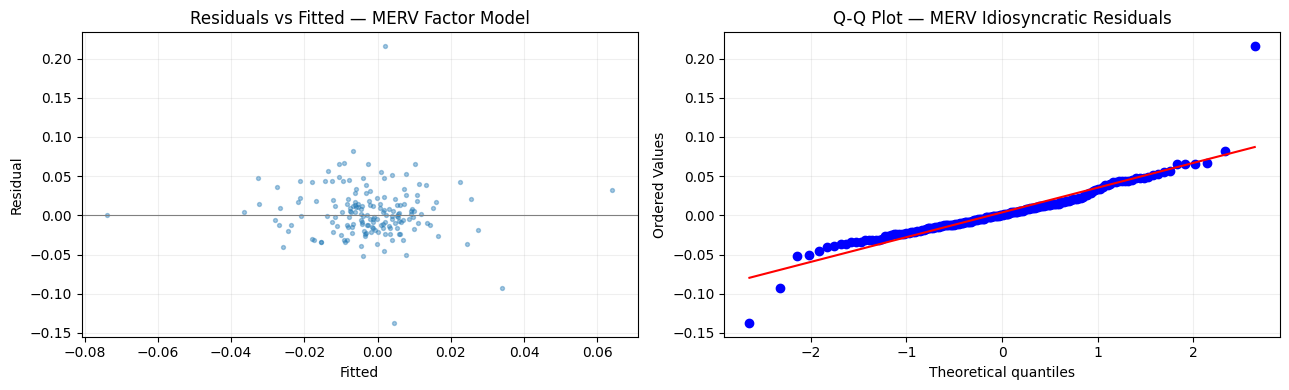

Saved: Images/argentina_factor_model_diagnostics.png


In [11]:
# Section 3a) Factor model residual diagnostics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "merged_inner" not in globals() or "MERV_idiosyncratic" not in merged_inner.columns:
    raise ValueError("MERV_idiosyncratic not found. Run the factor model cell first.")

resid = merged_inner["MERV_idiosyncratic"].dropna().copy()
fitted = merged_inner["MERV_fitted"].dropna().copy()
aligned = pd.concat([resid.rename("resid"), fitted.rename("fitted")], axis=1).dropna()

try:
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
    from statsmodels.regression.linear_model import OLS
    import statsmodels.api as sm

    # Ljung-Box at lags 5, 10, 20
    lb = acorr_ljungbox(aligned["resid"], lags=[5, 10, 20], return_df=True)
    print("Ljung-Box serial correlation test:")
    display(lb)

    # Durbin-Watson
    dw = durbin_watson(aligned["resid"].to_numpy())
    print(f"\nDurbin-Watson statistic: {dw:.4f}  (2.0 = no autocorrelation)")

    # Breusch-Pagan heteroskedasticity test
    X_bp = sm.add_constant(aligned["fitted"].to_numpy())
    bp_stat, bp_p, _, _ = het_breuschpagan(aligned["resid"].to_numpy(), X_bp)
    print(f"\nBreusch-Pagan heteroskedasticity: stat={bp_stat:.4f}, p={bp_p:.4f}")

    # Cook's distance (influence diagnostics)
    X_cd = sm.add_constant(aligned["fitted"].to_numpy())
    ols_res = OLS(aligned["resid"].to_numpy(), X_cd).fit()
    influence = ols_res.get_influence()
    cooks_d = influence.cooks_distance[0]
    top_idx = np.argsort(cooks_d)[-5:][::-1]
    print("\nTop-5 influential observations (Cook's D):")
    for pos in top_idx:
        orig_idx = aligned.index[pos]
        print(f"  {orig_idx}: Cook's D = {cooks_d[pos]:.4f}")

except ImportError:
    print("statsmodels not available. Skipping residual diagnostics.")

# Residual diagnostics panel
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(aligned["fitted"], aligned["resid"], alpha=0.4, s=8)
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_xlabel("Fitted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted — MERV Factor Model")
axes[0].grid(alpha=0.2)

from scipy import stats
stats.probplot(aligned["resid"].to_numpy(), plot=axes[1])
axes[1].set_title("Q-Q Plot — MERV Idiosyncratic Residuals")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.savefig("Images/argentina_factor_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Images/argentina_factor_model_diagnostics.png")

## 4) Exploratory Data Analysis

Examine the marginal distributions, autocorrelation structure, and stationarity of `MERV_idiosyncratic` and `LLA_returns` before model fitting. ADF and KPSS tests determine whether standard lag-based modeling is appropriate for each series.

Series: LLA_returns
Observations: 168


,mean,std,min,max,skew,kurtosis
LLA_returns,0.003159,0.051216,-0.2,0.42029,3.121676,27.48232


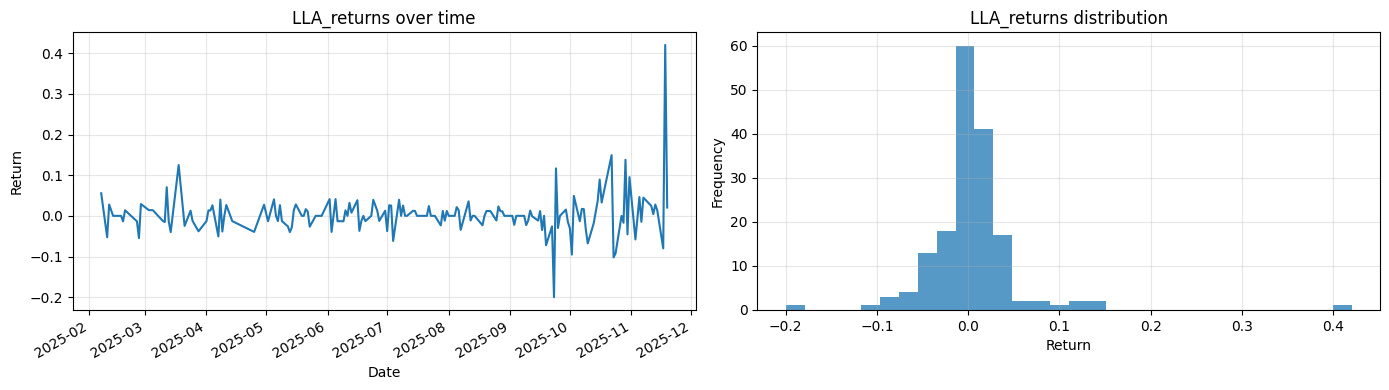

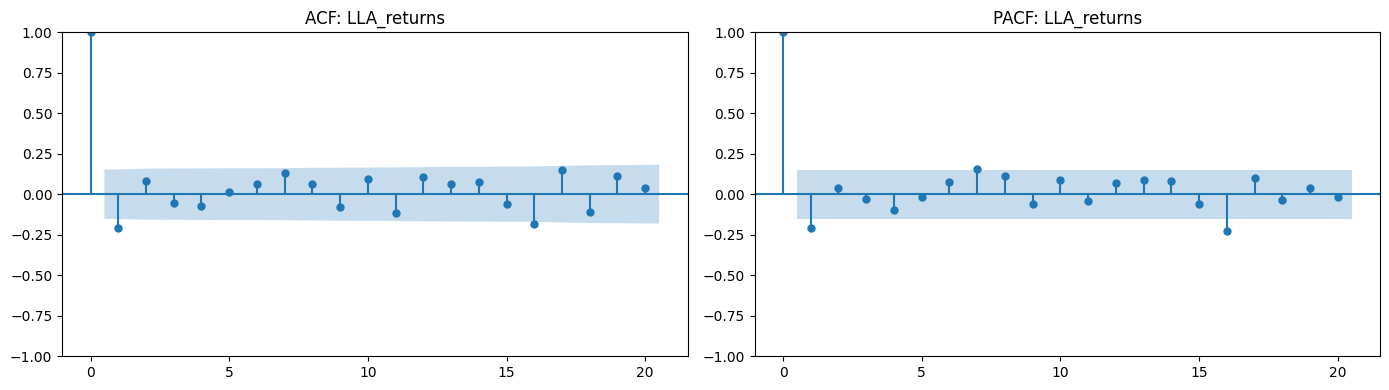

ADF statistic: 0.0775 | p-value: 0.9645
ADF conclusion (5%): Non-stationary
KPSS statistic: 0.2022 | p-value: 0.1000
KPSS conclusion (5%): Stationary

Series: MERV_idiosyncratic
Observations: 168


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_51829/408299860.py:77: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression='c', nlags='auto')


,mean,std,min,max,skew,kurtosis
MERV_idiosyncratic,0.003776,0.033507,-0.137105,0.215767,1.180916,10.391653


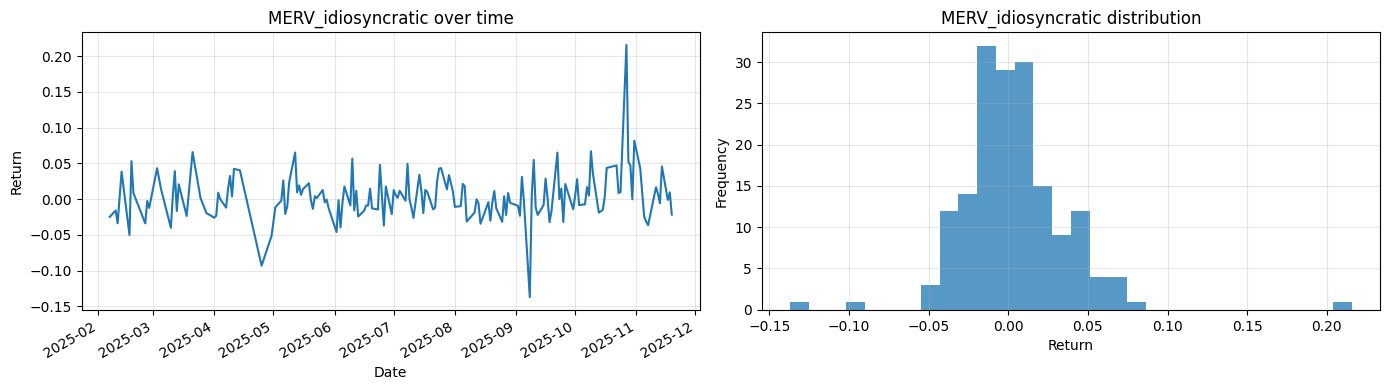

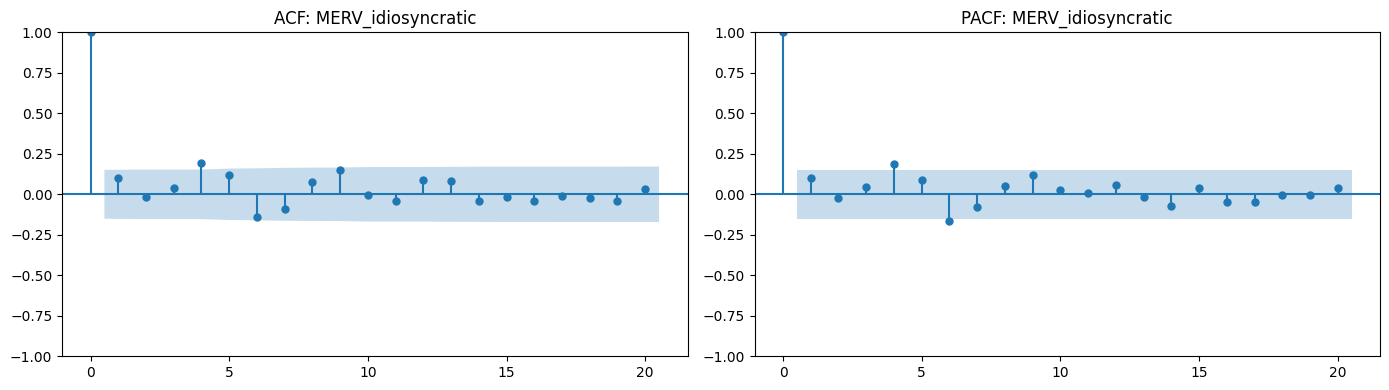

ADF statistic: -4.6349 | p-value: 0.0001
ADF conclusion (5%): Stationary
KPSS statistic: 0.3075 | p-value: 0.1000
KPSS conclusion (5%): Stationary



/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_51829/408299860.py:77: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression='c', nlags='auto')


In [12]:
# ====================================================
# Time-series EDA: LLA returns and MERV idiosyncratic returns
# Includes autocorrelation and stationarity checks
# ====================================================

try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    statsmodels_available = True
except Exception as exc:
    statsmodels_available = False
    print("statsmodels is required for ACF/PACF and ADF/KPSS tests.")
    print("Install with: pip install statsmodels")
    print("Import error:", exc)

series_map = {
    'LLA_returns': merged_inner.get('LLA_returns'),
    'MERV_idiosyncratic': merged_inner.get('MERV_idiosyncratic'),
}

if series_map['MERV_idiosyncratic'] is None:
    raise ValueError("MERV_idiosyncratic not found. Run the factor model cell first.")

for name, sr in series_map.items():
    sr = sr.dropna().copy()
    if sr.empty:
        print(f"Skipping {name}: no non-NaN observations.")
        continue

    print("=" * 70)
    print(f"Series: {name}")
    print(f"Observations: {len(sr)}")

    # Descriptive stats
    desc = pd.DataFrame({
        'mean': [sr.mean()],
        'std': [sr.std()],
        'min': [sr.min()],
        'max': [sr.max()],
        'skew': [sr.skew()],
        'kurtosis': [sr.kurt()],
    }, index=[name])
    display(desc)

    # Time-series and distribution view
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sr.plot(ax=axes[0], title=f'{name} over time')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Return')
    axes[0].grid(alpha=0.3)

    axes[1].hist(sr, bins=30, alpha=0.75)
    axes[1].set_title(f'{name} distribution')
    axes[1].set_xlabel('Return')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if statsmodels_available:
        # ACF / PACF
        max_lags = min(20, max(1, len(sr)//2 - 1))
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(sr, lags=max_lags, ax=axes[0])
        axes[0].set_title(f'ACF: {name}')
        plot_pacf(sr, lags=max_lags, ax=axes[1], method='ywm')
        axes[1].set_title(f'PACF: {name}')
        plt.tight_layout()
        plt.show()

        # Stationarity tests: ADF (H0: unit root), KPSS (H0: stationary)
        adf_stat, adf_p, *_ = adfuller(sr, autolag='AIC')
        print(f"ADF statistic: {adf_stat:.4f} | p-value: {adf_p:.4f}")
        print("ADF conclusion (5%):", "Stationary" if adf_p < 0.05 else "Non-stationary")

        try:
            kpss_stat, kpss_p, *_ = kpss(sr, regression='c', nlags='auto')
            print(f"KPSS statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}")
            print("KPSS conclusion (5%):", "Stationary" if kpss_p >= 0.05 else "Non-stationary")
        except Exception as kpss_exc:
            print("KPSS test failed:", kpss_exc)

        print()

**EDA interpretation note:** `MERV_idiosyncratic` passes both ADF and KPSS tests at the 5% level, confirming stationarity. `LLA_returns` passes ADF (rejecting the unit-root null) but KPSS also rejects its stationarity null at 5%, indicating volatility non-stationarity. This tension is consistent with a series that has no stochastic trend but whose variance changes over time as the election resolution date approaches. Working with the first-difference of LLA levels (i.e., LLA_returns) rather than the level addresses the main source of non-stationarity and is sufficient for lag-based modeling.

In [13]:
# ====================================================
# Modeling stage: causal-inference candidates (VAR, SVAR, VECM)
# Benchmark: information criteria (AIC/BIC) on the same sample
# Target relationship: LLA_returns -> MERV_idiosyncratic
# ====================================================

import warnings
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen

# Build modeling dataframe
model_cols = ['LLA_returns', 'MERV_idiosyncratic']
ts_df = merged_inner[model_cols].dropna().copy().reset_index(drop=True)

if len(ts_df) < 40:
    raise ValueError(f"Not enough observations for robust model comparison: {len(ts_df)}")

print(f"Total observations used for VAR/SVAR/VECM comparison: {len(ts_df)}")
display(ts_df.head())

max_lag = min(10, max(2, len(ts_df) // 8))

# -----------------------------
# VAR candidates
# -----------------------------
var_candidates = []
for p in range(1, max_lag + 1):
    try:
        fit = VAR(ts_df).fit(p)
        var_candidates.append({
            'Model': 'VAR',
            'lag': int(p),
            'k_ar_diff': np.nan,
            'coint_rank': np.nan,
            'AIC': float(fit.aic),
            'BIC': float(fit.bic),
            'HQIC': float(fit.hqic),
            'fit': fit,
        })
    except Exception as exc:
        print(f"VAR lag {p} failed: {exc}")

if not var_candidates:
    raise RuntimeError("All VAR candidates failed.")

# -----------------------------
# SVAR candidates (A-model: LLA contemporaneously affects MERV)
# -----------------------------
svar_candidates = []
A_template = np.array([[1, 0], ['E', 1]], dtype=object)

for p in range(1, max_lag + 1):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=FutureWarning)
            mod = SVAR(ts_df, svar_type='A', A=A_template)
            fit = mod.fit(maxlags=p, ic=None, trend='c', solver='nm', maxiter=2000, maxfun=4000)

        p_eff = int(fit.k_ar)
        if p_eff < 1:
            continue

        svar_candidates.append({
            'Model': 'SVAR',
            'lag': p_eff,
            'k_ar_diff': np.nan,
            'coint_rank': np.nan,
            'AIC': float(fit.aic),
            'BIC': float(fit.bic),
            'HQIC': float(fit.hqic),
            'fit': fit,
        })
    except Exception as exc:
        print(f"SVAR lag {p} failed: {exc}")

if not svar_candidates:
    print("SVAR candidates failed; proceeding with VAR/VECM results.")

# -----------------------------
# Cointegration test (Johansen trace test) and VECM candidates
# -----------------------------
vecm_candidates = []
cointegration_info = {'tested': False, 'rank_trace_5pct': 0, 'trace_table': None}

try:
    det_order = 0
    k_ar_diff_j = min(5, max(1, len(ts_df) // 20))
    johansen_res = coint_johansen(ts_df, det_order=det_order, k_ar_diff=k_ar_diff_j)

    trace_stats = johansen_res.lr1
    crit_5pct = johansen_res.cvt[:, 1]
    rank_trace_5pct = int(np.sum(trace_stats > crit_5pct))
    n_vars = ts_df.shape[1]

    trace_table = pd.DataFrame({
        'r <= i': [f"r <= {i}" for i in range(n_vars)],
        'trace_stat': trace_stats,
        'critical_5pct': crit_5pct,
        'reject_at_5pct': trace_stats > crit_5pct,
    })
    cointegration_info = {
        'tested': True,
        'rank_trace_5pct': rank_trace_5pct,
        'k_ar_diff_johansen': k_ar_diff_j,
        'trace_table': trace_table,
    }

    print("Johansen trace test (5% level):")
    display(trace_table)
    print(f"Inferred cointegration rank (trace, 5%): {rank_trace_5pct}")

    # For VECM, use reduced rank only if 1 <= rank < n_vars
    if 1 <= rank_trace_5pct < n_vars:
        vecm_rank = int(rank_trace_5pct)
        max_k_ar_diff = min(8, max(1, len(ts_df) // 10))
        for k_ar_diff in range(1, max_k_ar_diff + 1):
            try:
                fit = VECM(ts_df, coint_rank=vecm_rank, k_ar_diff=k_ar_diff, deterministic='co').fit()
                vecm_candidates.append({
                    'Model': 'VECM',
                    'lag': int(k_ar_diff + 1),
                    'k_ar_diff': int(k_ar_diff),
                    'coint_rank': int(vecm_rank),
                    'AIC': float(getattr(fit, 'aic', np.nan)),
                    'BIC': float(getattr(fit, 'bic', np.nan)),
                    'HQIC': float(getattr(fit, 'hqic', np.nan)),
                    'fit': fit,
                })
            except Exception as exc:
                print(f"VECM k_ar_diff {k_ar_diff} failed: {exc}")

        if not vecm_candidates:
            print("VECM considered but all candidates failed.")
    else:
        print("VECM not included: inferred rank is not in [1, n_vars-1].")
except Exception as exc:
    print(f"Cointegration/VECM step failed: {exc}")

# -----------------------------
# Combine and rank by BIC (primary) then AIC
# -----------------------------
all_candidates = var_candidates + svar_candidates + vecm_candidates
if not all_candidates:
    raise RuntimeError("No valid model candidates were estimated.")

model_compare_causal = pd.DataFrame([{k: v for k, v in c.items() if k != 'fit'} for c in all_candidates])
model_compare_causal = model_compare_causal.sort_values(['BIC', 'AIC'], na_position='last').reset_index(drop=True)

print("Causal-model comparison (lower is better):")
display(model_compare_causal)

# Best models by criterion
best_var = min(var_candidates, key=lambda x: x['BIC']) if var_candidates else None
best_svar = min(svar_candidates, key=lambda x: x['BIC']) if svar_candidates else None
best_vecm = None
if vecm_candidates:
    finite_vecm = [c for c in vecm_candidates if np.isfinite(c['BIC']) and np.isfinite(c['AIC'])]
    best_vecm = min(finite_vecm, key=lambda x: x['BIC']) if finite_vecm else None

selectable = [c for c in all_candidates if np.isfinite(c['BIC']) and np.isfinite(c['AIC'])]
if not selectable:
    raise RuntimeError("No candidates with finite AIC/BIC available for model selection.")

best_overall = min(selectable, key=lambda x: (x['BIC'], x['AIC']))

if best_var is not None:
    print(f"Best VAR by BIC: lag={best_var['lag']}, BIC={best_var['BIC']:.6f}, AIC={best_var['AIC']:.6f}")
if best_svar is not None:
    print(f"Best SVAR by BIC: lag={best_svar['lag']}, BIC={best_svar['BIC']:.6f}, AIC={best_svar['AIC']:.6f}")
if best_vecm is not None:
    print(
        f"Best VECM by BIC: k_ar_diff={best_vecm['k_ar_diff']}, coint_rank={best_vecm['coint_rank']}, "
        f"BIC={best_vecm['BIC']:.6f}, AIC={best_vecm['AIC']:.6f}"
    )

print(
    f"Selected overall causal model: {best_overall['Model']} "
    f"(lag={best_overall['lag']}, k_ar_diff={best_overall['k_ar_diff']})"
)

# Store for downstream scenario simulation
best_models_causal = {
    'VAR': best_var,
    'SVAR': best_svar,
    'VECM': best_vecm,
    'selected_model': best_overall['Model'],
    'selected_lag': best_overall['lag'],
    'selected_k_ar_diff': best_overall['k_ar_diff'],
    'model_compare_causal': model_compare_causal,
    'cointegration_info': cointegration_info,
    'ts_df': ts_df,
}

Total observations used for VAR/SVAR/VECM comparison: 168


,LLA_returns,MERV_idiosyncratic
0,0.055556,-0.024791
1,-0.052632,-0.015779
2,0.027778,-0.033683
3,0.000000,0.038512
4,0.000000,-0.050147


Johansen trace test (5% level):


,r <= i,trace_stat,critical_5pct,reject_at_5pct
0,r <= 0,35.350336,15.4943,True
1,r <= 1,10.315297,3.8415,True


Inferred cointegration rank (trace, 5%): 2
VECM not included: inferred rank is not in [1, n_vars-1].
Causal-model comparison (lower is better):


,Model,lag,k_ar_diff,coint_rank,AIC,BIC,HQIC
0,VAR,1,NaN,NaN,-12.740341,-12.628318,-12.694873
1,SVAR,1,NaN,NaN,-12.740341,-12.628318,-12.694873
2,VAR,2,NaN,NaN,-12.713943,-12.526474,-12.637848
3,SVAR,2,NaN,NaN,-12.713943,-12.526474,-12.637848
4,VAR,3,NaN,NaN,-12.684529,-12.420994,-12.577551
5,SVAR,3,NaN,NaN,-12.684529,-12.420994,-12.577551
6,VAR,4,NaN,NaN,-12.705202,-12.364973,-12.567082
7,SVAR,4,NaN,NaN,-12.705202,-12.364973,-12.567082
8,VAR,5,NaN,NaN,-12.671638,-12.254077,-12.502113
9,SVAR,5,NaN,NaN,-12.671638,-12.254077,-12.502113


Best VAR by BIC: lag=1, BIC=-12.628318, AIC=-12.740341
Best SVAR by BIC: lag=1, BIC=-12.628318, AIC=-12.740341
Selected overall causal model: VAR (lag=1, k_ar_diff=nan)


Backtest sample size: 168
Expanding window starts at train size: 50
Traditional settings used: VAR lag=1, SVAR lag=1, VECM k_ar_diff=1, rank=fallback
Backtest model ranking (lower RMSE/MAE is better; higher R2 is better):


,model,family,n_forecasts,rmse,mae,r2_backtest,directional_accuracy,pred_actual_corr
0,ElasticNet,ML,118,0.034686,0.022862,-0.008854,0.483051,-0.044630
1,Ridge,ML,118,0.034876,0.022975,-0.019980,0.457627,-0.160095
2,GradientBoosting,ML,118,0.035448,0.023669,-0.053712,0.440678,0.057093
3,ExtraTrees,ML,118,0.035454,0.023507,-0.054058,0.500000,0.003108
4,VAR,Traditional,118,0.035482,0.023353,-0.055686,0.457627,-0.062751
5,SVAR,Traditional,118,0.035482,0.023353,-0.055686,0.457627,-0.062751
6,RandomForest,ML,118,0.036320,0.024030,-0.106197,0.474576,-0.043965
7,SVR,ML,118,0.041845,0.029493,-0.468334,0.508475,-0.074435


Best backtested model: ElasticNet (ML) | RMSE=0.034686 | MAE=0.022862 | R2=-0.008854

Traditional vs ML family summary:


,family,n_models,best_rmse,median_rmse,best_mae,median_mae,best_r2,best_directional_accuracy
0,ML,6,0.034686,0.035451,0.022862,0.023588,-0.008854,0.508475
1,Traditional,2,0.035482,0.035482,0.023353,0.023353,-0.055686,0.457627


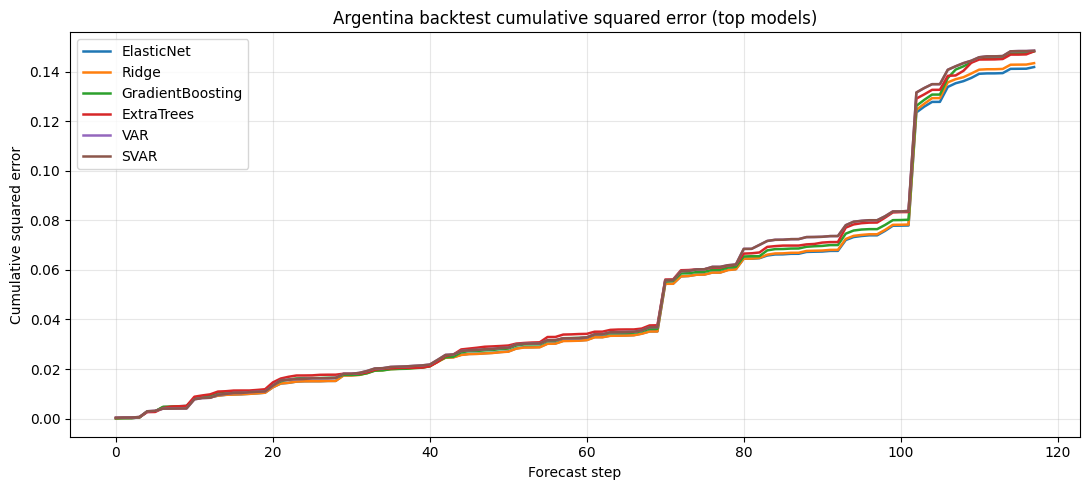

In [14]:
# ====================================================
# Expanding-window backtest: traditional vs ML models
# Target: MERV_idiosyncratic
# Features: lagged LLA_returns and lagged MERV_idiosyncratic
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.base import clone

if "ts_df" not in globals() or not isinstance(ts_df, pd.DataFrame):
    model_cols = ["LLA_returns", "MERV_idiosyncratic"]
    ts_df = merged_inner[model_cols].dropna().copy().reset_index(drop=True)

bt_df = ts_df[["LLA_returns", "MERV_idiosyncratic"]].dropna().copy().reset_index(drop=True)
if len(bt_df) < 80:
    raise ValueError(f"Need at least 80 observations for robust backtesting; got {len(bt_df)}")

n_lags_ml = 3
min_train = max(50, n_lags_ml + 20)
if len(bt_df) <= min_train + 10:
    raise ValueError(
        f"Not enough data for backtest with min_train={min_train}. Need > {min_train + 10}, got {len(bt_df)}."
    )

# Reuse benchmark-selected settings when available
var_lag_bt = 1
svar_lag_bt = 1
vecm_rank_bt = 1
vecm_kdiff_bt = 1
has_vecm_spec = False

if "best_models_causal" in globals() and isinstance(best_models_causal, dict):
    if best_models_causal.get("VAR") is not None:
        var_lag_bt = int(best_models_causal["VAR"].get("lag", 1))
    if best_models_causal.get("SVAR") is not None:
        svar_lag_bt = int(best_models_causal["SVAR"].get("lag", 1))
    if best_models_causal.get("VECM") is not None:
        vecm_rank_bt = int(best_models_causal["VECM"].get("coint_rank", 1))
        vecm_kdiff_bt = int(best_models_causal["VECM"].get("k_ar_diff", 1))
        has_vecm_spec = True

print(f"Backtest sample size: {len(bt_df)}")
print(f"Expanding window starts at train size: {min_train}")
print(
    f"Traditional settings used: VAR lag={var_lag_bt}, SVAR lag={svar_lag_bt}, "
    f"VECM k_ar_diff={vecm_kdiff_bt}, rank={vecm_rank_bt if has_vecm_spec else 'fallback'}"
)


def make_lagged_xy(df_slice, n_lags):
    rows = []
    for t in range(n_lags, len(df_slice)):
        rec = {"target": float(df_slice.iloc[t]["MERV_idiosyncratic"])}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(df_slice.iloc[t - lag]["LLA_returns"])
            rec[f"y_lag{lag}"] = float(df_slice.iloc[t - lag]["MERV_idiosyncratic"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feature_cols = [c for c in out.columns if c != "target"]
    return out[feature_cols], out["target"], feature_cols


def make_next_features(df_slice, n_lags, feature_cols):
    rec = {}
    for lag in range(1, n_lags + 1):
        rec[f"x_lag{lag}"] = float(df_slice.iloc[-lag]["LLA_returns"])
        rec[f"y_lag{lag}"] = float(df_slice.iloc[-lag]["MERV_idiosyncratic"])
    return pd.DataFrame([rec], columns=feature_cols)


def one_step_var(train_slice):
    try:
        fit = VAR(train_slice[["LLA_returns", "MERV_idiosyncratic"]]).fit(var_lag_bt)
        hist = train_slice[["LLA_returns", "MERV_idiosyncratic"]].to_numpy(dtype=float)[-fit.k_ar :]
        return float(fit.forecast(hist, steps=1)[0, 1])
    except Exception:
        return np.nan


def one_step_svar(train_slice):
    try:
        A_template = np.array([[1, 0], ["E", 1]], dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train_slice[["LLA_returns", "MERV_idiosyncratic"]], svar_type="A", A=A_template)
            fit = mod.fit(maxlags=svar_lag_bt, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)

        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        k_ar = int(coefs.shape[0])
        x_hist = train_slice["LLA_returns"].astype(float).tolist()
        y_hist = train_slice["MERV_idiosyncratic"].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            return np.nan

        y_next = float(intercept[1])
        for lag_i in range(1, k_ar + 1):
            A_lag = coefs[lag_i - 1]
            y_next += float(A_lag[1, 0]) * float(x_hist[-lag_i])
            y_next += float(A_lag[1, 1]) * float(y_hist[-lag_i])
        return float(y_next)
    except Exception:
        return np.nan


def one_step_vecm(train_slice):
    try:
        fit = VECM(
            train_slice[["LLA_returns", "MERV_idiosyncratic"]],
            coint_rank=vecm_rank_bt,
            k_ar_diff=vecm_kdiff_bt,
            deterministic="co",
        ).fit()
        coefs = np.array(fit.var_rep, dtype=float)
        det_coef = getattr(fit, "det_coef", None)
        if det_coef is not None and np.size(det_coef) > 0:
            intercept = np.array(det_coef, dtype=float)[:, 0]
        else:
            intercept = np.zeros(2, dtype=float)

        k_ar = int(coefs.shape[0])
        x_hist = train_slice["LLA_returns"].astype(float).tolist()
        y_hist = train_slice["MERV_idiosyncratic"].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            return np.nan

        y_next = float(intercept[1])
        for lag_i in range(1, k_ar + 1):
            A_lag = coefs[lag_i - 1]
            y_next += float(A_lag[1, 0]) * float(x_hist[-lag_i])
            y_next += float(A_lag[1, 1]) * float(y_hist[-lag_i])
        return float(y_next)
    except Exception:
        return np.nan


ml_model_space = {
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000),
    "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.01))]),
}


def _rmse_np(y_true_arr, y_pred_arr):
    return float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2)))


def fit_predict_with_early_stopping(model_name, estimator, X_train, y_train, X_next):
    n = len(X_train)
    split = int(n * 0.8)
    if n < 35 or split < 20 or (n - split) < 8:
        estimator.fit(X_train, y_train)
        return float(estimator.predict(X_next)[0])

    X_tr = X_train.iloc[:split]
    y_tr = y_train.iloc[:split]
    X_va = X_train.iloc[split:]
    y_va = y_train.iloc[split:]

    if model_name in ["RandomForest", "ExtraTrees"]:
        n_grid = [50, 100, 200, 300, 500]
        best_rmse = np.inf
        best_n = n_grid[0]
        worse_streak = 0
        for n_est in n_grid:
            est_try = clone(estimator).set_params(n_estimators=n_est)
            est_try.fit(X_tr, y_tr)
            score = _rmse_np(y_va.to_numpy(dtype=float), est_try.predict(X_va))
            if score + 1e-9 < best_rmse:
                best_rmse = score
                best_n = n_est
                worse_streak = 0
            else:
                worse_streak += 1
                if worse_streak >= 1:
                    break
        final_est = clone(estimator).set_params(n_estimators=best_n)
        final_est.fit(X_train, y_train)
        return float(final_est.predict(X_next)[0])

    if model_name == "GradientBoosting":
        est_try = GradientBoostingRegressor(
            random_state=42,
            learning_rate=0.05,
            max_depth=2,
            n_estimators=500,
        )
        est_try.fit(X_tr, y_tr)
        best_iter = 1
        best_rmse = np.inf
        worse_streak = 0
        for i, pred_stage in enumerate(est_try.staged_predict(X_va), start=1):
            score = _rmse_np(y_va.to_numpy(dtype=float), pred_stage)
            if score + 1e-9 < best_rmse:
                best_rmse = score
                best_iter = i
                worse_streak = 0
            else:
                worse_streak += 1
                if worse_streak >= 5:
                    break
        final_est = GradientBoostingRegressor(
            random_state=42,
            learning_rate=0.05,
            max_depth=2,
            n_estimators=max(10, best_iter),
        )
        final_est.fit(X_train, y_train)
        return float(final_est.predict(X_next)[0])

    estimator.fit(X_train, y_train)
    return float(estimator.predict(X_next)[0])


rows = []
for t in range(min_train, len(bt_df)):
    train_slice = bt_df.iloc[:t].copy()
    y_true = float(bt_df.iloc[t]["MERV_idiosyncratic"] )

    row = {"t": int(t), "y_true": y_true}
    row["VAR"] = one_step_var(train_slice)
    row["SVAR"] = one_step_svar(train_slice)
    row["VECM"] = one_step_vecm(train_slice) if has_vecm_spec else np.nan

    X_train, y_train, feat_cols = make_lagged_xy(train_slice, n_lags_ml)
    if len(X_train) < 25:
        for ml_name in ml_model_space.keys():
            row[ml_name] = np.nan
    else:
        X_next = make_next_features(train_slice, n_lags_ml, feat_cols)
        for ml_name, estimator in ml_model_space.items():
            try:
                row[ml_name] = fit_predict_with_early_stopping(
                    ml_name,
                    clone(estimator),
                    X_train,
                    y_train,
                    X_next,
                )
            except Exception:
                row[ml_name] = np.nan

    rows.append(row)

backtest_predictions_argentina = pd.DataFrame(rows)
model_cols = [c for c in backtest_predictions_argentina.columns if c not in ["t", "y_true"]]

metric_rows = []
for m in model_cols:
    tmp = backtest_predictions_argentina[["y_true", m]].dropna().copy()
    if len(tmp) == 0:
        continue
    y_true_arr = tmp["y_true"].to_numpy(dtype=float)
    y_pred_arr = tmp[m].to_numpy(dtype=float)
    err = y_pred_arr - y_true_arr
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true_arr - y_true_arr.mean()) ** 2))
    r2_backtest = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    dir_acc = float(np.mean(np.sign(tmp[m].to_numpy()) == np.sign(tmp["y_true"].to_numpy())))
    corr = float(tmp[m].corr(tmp["y_true"])) if len(tmp) > 2 else np.nan
    metric_rows.append({
        "model": m,
        "family": "Traditional" if m in ["VAR", "SVAR", "VECM"] else "ML",
        "n_forecasts": int(len(tmp)),
        "rmse": rmse,
        "mae": mae,
        "r2_backtest": r2_backtest,
        "directional_accuracy": dir_acc,
        "pred_actual_corr": corr,
    })

backtest_metrics_argentina = pd.DataFrame(metric_rows).sort_values(["rmse", "mae"]).reset_index(drop=True)

print("Backtest model ranking (lower RMSE/MAE is better; higher R2 is better):")
display(backtest_metrics_argentina)

if not backtest_metrics_argentina.empty:
    best_model_backtest_argentina = backtest_metrics_argentina.iloc[0].to_dict()
    print(
        f"Best backtested model: {best_model_backtest_argentina['model']} "
        f"({best_model_backtest_argentina['family']}) | RMSE={best_model_backtest_argentina['rmse']:.6f} | "
        f"MAE={best_model_backtest_argentina['mae']:.6f} | R2={best_model_backtest_argentina['r2_backtest']:.6f}"
    )

family_summary = (
    backtest_metrics_argentina.groupby("family", as_index=False)
    .agg(
        n_models=("model", "count"),
        best_rmse=("rmse", "min"),
        median_rmse=("rmse", "median"),
        best_mae=("mae", "min"),
        median_mae=("mae", "median"),
        best_r2=("r2_backtest", "max"),
        best_directional_accuracy=("directional_accuracy", "max"),
    )
    .sort_values("best_rmse")
    .reset_index(drop=True)
)

print("\nTraditional vs ML family summary:")
display(family_summary)

top_models = backtest_metrics_argentina.head(6)["model"].tolist() if not backtest_metrics_argentina.empty else []
if top_models:
    plt.figure(figsize=(11, 5))
    for m in top_models:
        tmp = backtest_predictions_argentina[["y_true", m]].dropna().copy()
        se = (tmp[m] - tmp["y_true"]) ** 2
        plt.plot(np.arange(len(se)), se.cumsum(), linewidth=1.8, label=m)
    plt.title("Argentina backtest cumulative squared error (top models)")
    plt.xlabel("Forecast step")
    plt.ylabel("Cumulative squared error")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
import numpy as np
import pandas as pd

# Provide safe fallbacks so this diagnostic cell can run after data prep
if "sim_df" not in globals():
    # try to build sim_df from merged_inner if possible
    lla_col = globals().get("lla_col", "LLA (La Libertad Avanza)")
    need_cols = [lla_col, "LLA_returns", "MERV_idiosyncratic", "^MERV"]
    if "merged_inner" in globals():
        missing = [c for c in need_cols if c not in merged_inner.columns]
        if missing:
            raise ValueError(f"Cannot build sim_df: missing columns in merged_inner: {missing}")
        sim_df = merged_inner[need_cols].dropna().copy()
    else:
        raise ValueError("Run the simulation cell first so sim_df, t0_idx, and horizon are available.")

# infer horizon if not present
if "horizon" not in globals():
    horizon = int(globals().get("horizon", 5))
else:
    horizon = int(horizon)

# infer t0_idx if missing (use last available index before horizon)
if "t0_idx" not in globals():
    if len(sim_df) <= horizon:
        raise ValueError(f"Need at least horizon+1 rows in sim_df to infer t0_idx; got {len(sim_df)}")
    t0_idx = sim_df.index[-(horizon + 1)]

# Prepare the future slice and ensure required helper objects are present
future_slice = sim_df.loc[sim_df.index > t0_idx, ["LLA_returns", "MERV_idiosyncratic"]].head(horizon).copy()
if len(future_slice) < horizon:
    raise ValueError(f"Need {horizon} future observations after the simulation anchor; got {len(future_slice)}.")

actual_lla_future_rets = future_slice["LLA_returns"].to_numpy(dtype=float)
actual_merv_idio = future_slice["MERV_idiosyncratic"].to_numpy(dtype=float)

# Ensure train_sim is available; if not, build a basic train slice from sim_df
if "train_sim" not in globals():
    train_sim = sim_df.loc[:t0_idx, ["LLA_returns", "MERV_idiosyncratic"]].copy()

# Ensure prediction function exists; provide a lightweight fallback if missing
if "run_model_for_path" not in globals():
    # fallback: simple linear regression of idio on LLA_returns
    try:
        from sklearn.linear_model import LinearRegression
    except Exception:
        raise ValueError("sklearn is required for fallback run_model_for_path. Install scikit-learn or run the modeling cells.")
    def run_model_for_path(train_data, lla_future_rets):
        # train_data: DataFrame with columns ['LLA_returns', 'MERV_idiosyncratic']
        X = train_data[["LLA_returns"]].astype(float).fillna(0.0).values.reshape(-1, 1)
        y = train_data["MERV_idiosyncratic"].astype(float).fillna(0.0).values
        if len(y) == 0:
            return np.zeros(len(lla_future_rets), dtype=float)
        if len(y) < 3:
            return np.full(len(lla_future_rets), float(np.mean(y)))
        model_lr = LinearRegression().fit(X, y)
        preds = []
        for val in lla_future_rets:
            p = model_lr.predict(np.array([[float(val)]]))[0]
            preds.append(float(p))
        return np.asarray(preds, dtype=float)

predicted_merv_idio = run_model_for_path(train_sim, actual_lla_future_rets)

if len(predicted_merv_idio) != len(actual_merv_idio):
    raise RuntimeError("Prediction and actual horizon lengths do not match.")

sse = float(np.sum((actual_merv_idio - predicted_merv_idio) ** 2))
sst = float(np.sum((actual_merv_idio - actual_merv_idio.mean()) ** 2))
oos_r2 = float(1.0 - sse / sst) if sst > 0 else np.nan
rmse = float(np.sqrt(np.mean((actual_merv_idio - predicted_merv_idio) ** 2)))
mae = float(np.mean(np.abs(actual_merv_idio - predicted_merv_idio)))

# selected_model / selected_window may not be set in all flows; provide safe defaults
selected_model = globals().get("selected_model", globals().get("selected_simulation_model", None))
selected_window = globals().get("selected_window", globals().get("selected_window_days", None))

simulation_holdout_metrics = pd.DataFrame(
    {
        "metric": ["oos_r2", "rmse", "mae", "selected_model", "selected_window_days"],
        "value": [oos_r2, rmse, mae, selected_model, selected_window],
    }
)

after_simulation_holdout = pd.DataFrame(
    {
        "actual_merv_idiosyncratic": actual_merv_idio,
        "predicted_merv_idiosyncratic": predicted_merv_idio,
        "error": actual_merv_idio - predicted_merv_idio,
    }
)

print("Out-of-sample holdout for the simulation model (window after T0):")
display(simulation_holdout_metrics)
display(after_simulation_holdout)

print(f"Simulation-model out-of-sample R^2: {oos_r2:.6f}")


Out-of-sample holdout for the simulation model (window after T0):


,metric,value
0,oos_r2,-0.020490
1,rmse,0.022758
2,mae,0.017723
3,selected_model,NaN
4,selected_window_days,NaN


,actual_merv_idiosyncratic,predicted_merv_idiosyncratic,error
0,-0.005804,0.004663,-0.010467
1,0.045712,0.004168,0.041544
2,-0.001030,0.000926,-0.001956
3,0.009612,0.018271,-0.008659
4,-0.021579,0.004407,-0.025987


Simulation-model out-of-sample R^2: -0.020490


## 5) Predictive Modeling and Model Selection

Two-stage model comparison across VAR, SVAR, VECM, GARCH, and nine machine-learning specifications. Stage 1 is a fixed holdout bakeoff (RMSE, MAE, directional accuracy). Stage 2 is expanding-window and rolling-window generalizability evaluation. The model with the best combined rank is selected for simulation.

### 5a) VAR / SVAR / VECM Benchmark Fitting

Fit VAR, recursive SVAR, and VECM candidates. Johansen cointegration test determines whether a VECM specification is warranted. VAR and SVAR lag orders are selected by holdout RMSE, not information criteria, for consistency with the cross-model comparison criterion. VECM lag and cointegration rank are selected by the Johansen trace test.

### 5b) Expanding-Window Backtest and Final Model Selection

One-step-ahead backtest across all candidate models. Stage 1 holdout bakeoff produces `bakeoff_summary`. Stage 2 expanding-window and rolling-window validation produces `generalization_summary` with a composite rank score. The final model is selected by summing bakeoff rank and composite validation rank, giving both stages equal weight. Result stored in `best_models`.

/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00187. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001837. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resid

Expanding-window backtest complete (Traditional + ML + GARCH + Foundation).
Resolution date used for time_to_expiry: 2025-11-19
Time-to-expiry range: 20410 to 20411 days
Total tests: 1296
Successful fits: 1296
Best overall: model=ElasticNet (ML) | window=148 days | RMSE=0.018853 | MAE=0.012526 | R2=0.299694
Best window per model:


,model,family,train_window_days,k_ar_used,lag_info,rmse,mae,r2_backtest
0,ElasticNet,ML,148,3,3,0.018853,0.012526,2.996938e-01
1,Ridge,ML,150,3,3,0.018910,0.012026,2.954084e-01
2,VECM,Traditional,144,2,1,0.019153,0.013813,2.771855e-01
3,GradientBoosting,ML,134,3,3,0.019608,0.015586,2.424162e-01
4,VAR,Traditional,151,1,1,0.019849,0.012600,2.237235e-01
5,SVAR,Traditional,151,1,1,0.019849,0.012600,2.237235e-01
6,RandomForest,ML,81,3,3,0.019952,0.016990,2.156114e-01
7,GARCH,GARCH,89,1,1,0.022327,0.017777,1.778750e-02
8,ExtraTrees,ML,90,3,3,0.022370,0.016025,1.402311e-02
9,FoundationModel,Foundation,147,3,3,0.022374,0.019924,1.364006e-02


Family summary:


,family,n_models,best_rmse,median_rmse,best_mae,best_r2
0,ML,7,0.018853,0.025101,0.011648,0.299694
1,Traditional,3,0.019153,0.024131,0.012029,0.277186
2,GARCH,1,0.022327,0.022614,0.017013,0.017787
3,Foundation,1,0.022374,0.026552,0.019378,0.013640


Top 20 model-window combos by RMSE:


,model,family,train_window_days,rmse,mae,r2_backtest,k_ar_used,lag_info
0,ElasticNet,ML,148,0.018853,0.012526,0.299694,3,3
1,Ridge,ML,150,0.018910,0.012026,0.295408,3,3
2,ElasticNet,ML,153,0.018927,0.012498,0.294133,3,3
3,ElasticNet,ML,152,0.018940,0.012494,0.293213,3,3
4,Ridge,ML,161,0.018957,0.011829,0.291917,3,3
5,Ridge,ML,149,0.018958,0.011871,0.291829,3,3
6,Ridge,ML,163,0.018969,0.011833,0.291009,3,3
7,Ridge,ML,162,0.018970,0.011834,0.290969,3,3
8,Ridge,ML,148,0.018982,0.013080,0.290054,3,3
9,Ridge,ML,157,0.018983,0.011663,0.289992,3,3


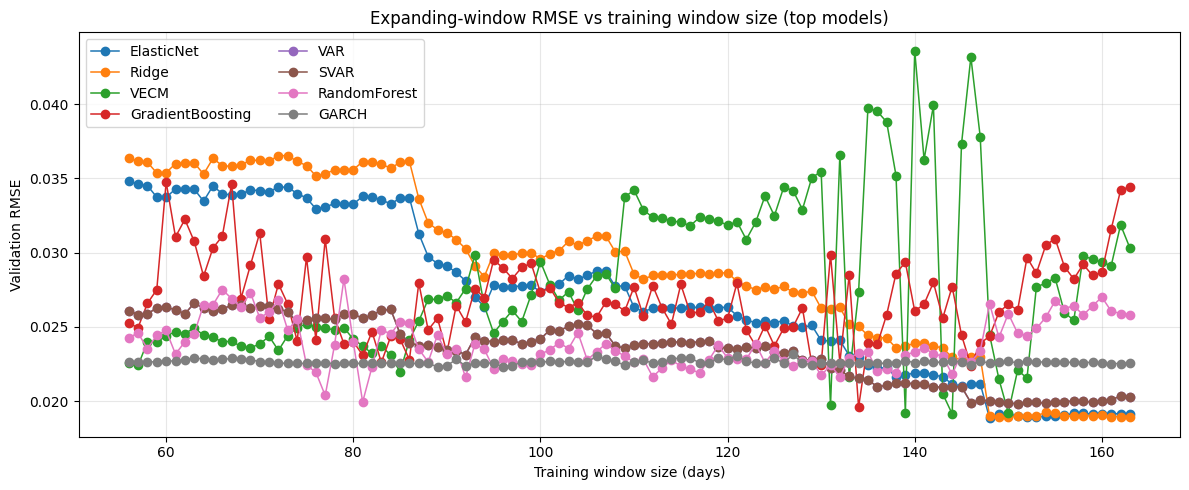

In [16]:
# ====================================================
# Expanding-window backtest across Traditional + ML + GARCH + Foundation
# Goal: select best model-window combo by out-of-sample RMSE
# ML/Foundation candidates include time_to_expiry feature
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

try:
    from arch import arch_model
    HAS_ARCH = True
except Exception:
    HAS_ARCH = False

resolution_date = pd.Timestamp("2025-11-19")

if "ts_df" not in globals() or not isinstance(ts_df, pd.DataFrame):
    base = merged_inner[["LLA_returns", "MERV_idiosyncratic"]].dropna().copy().reset_index()
    base = base.rename(columns={"index": "timestamp"})
    base["timestamp"] = pd.to_datetime(base["timestamp"], errors="coerce")
    base = base.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    base["time_to_expiry"] = (resolution_date - base["timestamp"]).dt.days.clip(lower=0)
    ts_df = base[["timestamp", "LLA_returns", "MERV_idiosyncratic", "time_to_expiry"]].dropna().reset_index(drop=True)
else:
    ts_df = ts_df.copy()
    if "timestamp" not in ts_df.columns:
        ts_df = ts_df.reset_index().rename(columns={"index": "timestamp"})
    ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
    if "time_to_expiry" not in ts_df.columns:
        ts_df["time_to_expiry"] = (resolution_date - ts_df["timestamp"]).dt.days.clip(lower=0)
    ts_df = ts_df[["timestamp", "LLA_returns", "MERV_idiosyncratic", "time_to_expiry"]].dropna().sort_values("timestamp").reset_index(drop=True)

if len(ts_df) < 60:
    raise ValueError(f"Not enough observations for expanding-window test: {len(ts_df)}")

_n_obs = len(ts_df)
min_window = max(30, _n_obs // 3)
val_horizon = 5
n_lags_ml = 3

if len(ts_df) <= min_window + val_horizon:
    raise ValueError(
        f"Need more data for min_window={min_window} and val_horizon={val_horizon}; got {len(ts_df)} rows."
    )

var_lag = 1
svar_lag = 1
vecm_k_ar_diff = 1
vecm_rank = 1

if "best_models_causal" in globals() and isinstance(best_models_causal, dict):
    if best_models_causal.get("VAR") is not None:
        var_lag = int(best_models_causal["VAR"].get("lag", 1))
    if best_models_causal.get("SVAR") is not None:
        svar_lag = int(best_models_causal["SVAR"].get("lag", 1))
    if best_models_causal.get("VECM") is not None:
        vecm_k_ar_diff = int(best_models_causal["VECM"].get("k_ar_diff", 1))
        vecm_rank = int(best_models_causal["VECM"].get("coint_rank", 1))

A_template = np.array([[1, 0], ["E", 1]], dtype=object)

n_total = len(ts_df)
train_end = n_total - val_horizon
val_df = ts_df.iloc[train_end:].copy()
x_val = val_df["LLA_returns"].to_numpy(dtype=float)
y_val = val_df["MERV_idiosyncratic"].to_numpy(dtype=float)
tte_val = val_df["time_to_expiry"].to_numpy(dtype=float)


def fit_model(train_slice: pd.DataFrame, model_name: str):
    _endog_cols = ["LLA_returns", "MERV_idiosyncratic"]
    if model_name == "VAR":
        _endog = train_slice[_endog_cols].copy()
        _exog_arr = None
        if "time_to_expiry" in train_slice.columns:
            _exog_arr = train_slice[["time_to_expiry"]].to_numpy(dtype=float)
        fit = VAR(_endog, exog=_exog_arr).fit(var_lag) if _exog_arr is not None else VAR(_endog).fit(var_lag)
        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        return {
            "fit_obj": fit,
            "coefs": coefs,
            "intercept": intercept,
            "k_ar": int(coefs.shape[0]),
            "lag_info": int(var_lag),
            "has_exog": _exog_arr is not None,
        }

    if model_name == "SVAR":
        _endog = train_slice[_endog_cols].copy()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(_endog, svar_type="A", A=A_template)
            fit = mod.fit(maxlags=svar_lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        return {"coefs": coefs, "intercept": intercept, "k_ar": int(coefs.shape[0]), "lag_info": int(svar_lag)}

    if model_name == "VECM":
        _endog = train_slice[_endog_cols].copy()
        fit = VECM(_endog, coint_rank=vecm_rank, k_ar_diff=vecm_k_ar_diff, deterministic="co").fit()
        coefs = np.array(fit.var_rep, dtype=float)
        det_coef = getattr(fit, "det_coef", None)
        if det_coef is not None and np.size(det_coef) > 0:
            intercept = np.array(det_coef, dtype=float)[:, 0]
        else:
            intercept = np.zeros(_endog.shape[1], dtype=float)
        return {"coefs": coefs, "intercept": intercept, "k_ar": int(coefs.shape[0]), "lag_info": int(vecm_k_ar_diff)}

    raise ValueError(f"Unsupported model_name: {model_name}")


def recursive_forecast_y_given_x(train_slice: pd.DataFrame, model_artifacts: dict,
                                 x_future: np.ndarray, tte_future: np.ndarray = None) -> np.ndarray:
    coefs = np.array(model_artifacts["coefs"], dtype=float)
    intercept = np.array(model_artifacts["intercept"], dtype=float)
    k_ar = int(model_artifacts["k_ar"])
    fit_obj = model_artifacts.get("fit_obj")
    has_exog = model_artifacts.get("has_exog", False)

    x_hist = train_slice["LLA_returns"].astype(float).tolist()
    y_hist = train_slice["MERV_idiosyncratic"].astype(float).tolist()
    if len(x_hist) < k_ar or len(y_hist) < k_ar:
        raise RuntimeError(f"Not enough history for lag order {k_ar}.")

    if fit_obj is not None and has_exog and tte_future is not None:
        # Use fit.forecast() which handles exog internally
        hist_arr = np.column_stack([x_hist[-k_ar:], y_hist[-k_ar:]])
        preds = []
        for step_i, x_next in enumerate(x_future):
            tte_next = np.array([[float(tte_future[step_i])]])
            fc = fit_obj.forecast(hist_arr, steps=1, exog_future=tte_next)
            y_next = float(fc[0, 1])  # index 1 = MERV_idiosyncratic
            preds.append(y_next)
            hist_arr = np.vstack([hist_arr[1:], [float(x_next), y_next]])
        return np.array(preds, dtype=float)

    # Fallback: manual recursive forecast (no exog or exog unavailable)
    preds = []
    for x_next in x_future:
        y_next = float(intercept[1])
        for lag_i in range(1, k_ar + 1):
            A_lag = coefs[lag_i - 1]
            y_next += float(A_lag[1, 0]) * float(x_hist[-lag_i])
            y_next += float(A_lag[1, 1]) * float(y_hist[-lag_i])
        preds.append(y_next)
        x_hist.append(float(x_next))
        y_hist.append(y_next)

    return np.array(preds, dtype=float)


def build_lagged_xy(train_slice: pd.DataFrame, n_lags: int):
    rows = []
    x_vals = train_slice["LLA_returns"].to_numpy(dtype=float)
    y_vals = train_slice["MERV_idiosyncratic"].to_numpy(dtype=float)
    tte_vals = train_slice["time_to_expiry"].to_numpy(dtype=float)
    for t in range(n_lags, len(train_slice)):
        rec = {"target": y_vals[t]}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = x_vals[t - lag]
            rec[f"y_lag{lag}"] = y_vals[t - lag]
            rec[f"tte_lag{lag}"] = tte_vals[t - lag]
        rec["tte_current"] = tte_vals[t]
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feat_cols = [c for c in out.columns if c != "target"]
    return out[feat_cols], out["target"], feat_cols


def recursive_ml_forecast(train_slice: pd.DataFrame, x_future: np.ndarray, tte_future: np.ndarray, model_name: str, n_lags: int, params: dict):
    X_train, y_train, feat_cols = build_lagged_xy(train_slice, n_lags)
    if len(X_train) < 25:
        raise RuntimeError("Too few rows for lagged ML training.")

    if model_name == "Ridge":
        est = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=params.get("alpha", 1.0)))])
    elif model_name == "Lasso":
        est = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=params.get("alpha", 0.01), max_iter=20000, random_state=42))])
    elif model_name == "ElasticNet":
        est = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=params.get("alpha", 0.001), l1_ratio=params.get("l1_ratio", 0.5), max_iter=20000, random_state=42))])
    elif model_name == "SVR":
        est = Pipeline([("scaler", StandardScaler()), ("model", SVR(C=params.get("C", 1.0), epsilon=params.get("epsilon", 0.1), gamma=params.get("gamma", "scale"), kernel=params.get("kernel", "rbf")))])
    elif model_name == "RandomForest":
        est = RandomForestRegressor(n_estimators=params.get("n_estimators", 300), max_depth=params.get("max_depth", 5), min_samples_leaf=params.get("min_samples_leaf", 2), random_state=42)
    elif model_name == "ExtraTrees":
        est = ExtraTreesRegressor(n_estimators=params.get("n_estimators", 300), max_depth=params.get("max_depth", 5), min_samples_leaf=params.get("min_samples_leaf", 2), random_state=42)
    elif model_name == "GradientBoosting":
        est = GradientBoostingRegressor(n_estimators=params.get("n_estimators", 300), learning_rate=params.get("learning_rate", 0.03), max_depth=params.get("max_depth", 2), random_state=42)
    elif model_name == "FoundationModel":
        est = GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42)
    else:
        raise ValueError(f"Unsupported ML/Foundation model: {model_name}")

    est.fit(X_train, y_train)

    x_hist = train_slice["LLA_returns"].astype(float).tolist()
    y_hist = train_slice["MERV_idiosyncratic"].astype(float).tolist()
    tte_hist = train_slice["time_to_expiry"].astype(float).tolist()
    preds = []
    for step, x_next in enumerate(x_future):
        row = {}
        for lag in range(1, n_lags + 1):
            row[f"x_lag{lag}"] = float(x_hist[-lag])
            row[f"y_lag{lag}"] = float(y_hist[-lag])
            row[f"tte_lag{lag}"] = float(tte_hist[-lag])
        row["tte_current"] = float(tte_future[step])
        y_next = float(est.predict(pd.DataFrame([row], columns=feat_cols))[0])
        preds.append(y_next)
        x_hist.append(float(x_next))
        y_hist.append(y_next)
        tte_hist.append(float(tte_future[step]))
    return np.array(preds, dtype=float)


def recursive_garch_forecast(train_slice: pd.DataFrame, x_future: np.ndarray):
    if not HAS_ARCH:
        raise RuntimeError("arch package not available for GARCH model.")
    y_hist = train_slice["MERV_idiosyncratic"].astype(float).tolist()
    preds = []
    for _ in x_future:
        am = arch_model(np.array(y_hist, dtype=float), vol="Garch", p=1, q=1, mean="AR", lags=1)
        fit = am.fit(disp="off")
        y_next = float(fit.forecast(horizon=1).mean.iloc[-1, 0])
        preds.append(y_next)
        y_hist.append(y_next)
    return np.array(preds, dtype=float)


model_specs = [
    ("VAR", "Traditional", {"model": "VAR", "uses_tte": False}),
    ("SVAR", "Traditional", {"model": "SVAR", "uses_tte": False}),
    ("VECM", "Traditional", {"model": "VECM", "uses_tte": False}),
    ("Ridge", "ML", {"model": "Ridge", "n_lags": n_lags_ml, "params": {"alpha": 1.0}, "uses_tte": True}),
    ("Lasso", "ML", {"model": "Lasso", "n_lags": n_lags_ml, "params": {"alpha": 0.01}, "uses_tte": True}),
    ("ElasticNet", "ML", {"model": "ElasticNet", "n_lags": n_lags_ml, "params": {"alpha": 0.001, "l1_ratio": 0.5}, "uses_tte": True}),
    ("RandomForest", "ML", {"model": "RandomForest", "n_lags": n_lags_ml, "params": {"n_estimators": 300, "max_depth": 5, "min_samples_leaf": 2}, "uses_tte": True}),
    ("ExtraTrees", "ML", {"model": "ExtraTrees", "n_lags": n_lags_ml, "params": {"n_estimators": 300, "max_depth": 5, "min_samples_leaf": 2}, "uses_tte": True}),
    ("GradientBoosting", "ML", {"model": "GradientBoosting", "n_lags": n_lags_ml, "params": {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 2}, "uses_tte": True}),
    ("SVR", "ML", {"model": "SVR", "n_lags": n_lags_ml, "params": {"C": 1.0, "epsilon": 0.1, "gamma": "scale", "kernel": "rbf"}, "uses_tte": True}),
    ("GARCH", "GARCH", {"model": "GARCH", "uses_tte": False}),
    ("FoundationModel", "Foundation", {"model": "FoundationModel", "n_lags": n_lags_ml, "params": {}, "uses_tte": True}),
]

rows = []
for model_name, family, spec in model_specs:
    for window_size in range(min_window, train_end + 1):
        train_start = train_end - window_size
        train_slice = ts_df.iloc[train_start:train_end].copy()
        train_trad = train_slice[["LLA_returns", "MERV_idiosyncratic"]].copy()
        try:
            if model_name in ["VAR", "SVAR", "VECM"]:
                if model_name == "VAR":
                    artifacts = fit_model(train_slice, model_name)  # full slice: TTE passed as exog
                    y_pred = recursive_forecast_y_given_x(train_slice, artifacts, x_val, tte_val)
                else:
                    artifacts = fit_model(train_trad, model_name)  # 2-col only for SVAR/VECM
                    y_pred = recursive_forecast_y_given_x(train_trad, artifacts, x_val)
                k_ar = int(artifacts["k_ar"])
                lag_info = int(artifacts["lag_info"])
            elif model_name == "GARCH":
                y_pred = recursive_garch_forecast(train_slice, x_val)
                k_ar = 1
                lag_info = 1
            else:
                y_pred = recursive_ml_forecast(
                    train_slice,
                    x_val,
                    tte_val,
                    spec["model"],
                    int(spec.get("n_lags", n_lags_ml)),
                    dict(spec.get("params", {})),
                )
                k_ar = int(spec.get("n_lags", n_lags_ml))
                lag_info = int(spec.get("n_lags", n_lags_ml))

            rmse = float(np.sqrt(np.mean((y_val - y_pred) ** 2)))
            mae = float(np.mean(np.abs(y_val - y_pred)))
            ss_res = float(np.sum((y_val - y_pred) ** 2))
            ss_tot = float(np.sum((y_val - y_val.mean()) ** 2))
            r2_backtest = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
            rows.append({
                "model": model_name,
                "family": family,
                "train_window_days": int(window_size),
                "train_start_idx": int(train_start),
                "train_end_idx": int(train_end - 1),
                "val_horizon_days": int(val_horizon),
                "k_ar_used": k_ar,
                "lag_info": lag_info,
                "rmse": rmse,
                "mae": mae,
                "r2_backtest": r2_backtest,
                "fit_ok": True,
                "spec": spec,
            })
        except Exception as exc:
            rows.append({
                "model": model_name,
                "family": family,
                "train_window_days": int(window_size),
                "train_start_idx": int(train_start),
                "train_end_idx": int(train_end - 1),
                "val_horizon_days": int(val_horizon),
                "k_ar_used": np.nan,
                "lag_info": np.nan,
                "rmse": np.nan,
                "mae": np.nan,
                "r2_backtest": np.nan,
                "fit_ok": False,
                "error": str(exc),
                "spec": spec,
            })

window_backtest_all = pd.DataFrame(rows)
ok = window_backtest_all[window_backtest_all["fit_ok"]].copy()

if ok.empty:
    raise RuntimeError("All expanding-window fits failed across model families.")

ok_ranked = ok.sort_values(["rmse", "mae"]).reset_index(drop=True)
best_row = ok_ranked.iloc[0]

best_by_model = (
    ok.sort_values(["model", "rmse", "mae"])
      .groupby(["model", "family"], as_index=False)
      .first()
      .sort_values("rmse")
      .reset_index(drop=True)
)

family_summary = (
    ok.groupby("family", as_index=False)
      .agg(
          n_models=("model", "nunique"),
          best_rmse=("rmse", "min"),
          median_rmse=("rmse", "median"),
          best_mae=("mae", "min"),
          best_r2=("r2_backtest", "max"),
      )
      .sort_values("best_rmse")
      .reset_index(drop=True)
)

print("Expanding-window backtest complete (Traditional + ML + GARCH + Foundation).")
print(f"Resolution date used for time_to_expiry: {resolution_date.date()}")
print(f"Time-to-expiry range: {int(ts_df['time_to_expiry'].min())} to {int(ts_df['time_to_expiry'].max())} days")
print(f"Total tests: {len(window_backtest_all)}")
print(f"Successful fits: {len(ok)}")
print(
    f"Best overall: model={best_row['model']} ({best_row['family']}) | window={int(best_row['train_window_days'])} days | "
    f"RMSE={best_row['rmse']:.6f} | MAE={best_row['mae']:.6f} | R2={best_row['r2_backtest']:.6f}"
)
print("Best window per model:")
display(best_by_model[["model", "family", "train_window_days", "k_ar_used", "lag_info", "rmse", "mae", "r2_backtest"]])
print("Family summary:")
display(family_summary)
print("Top 20 model-window combos by RMSE:")
display(ok_ranked.head(20)[["model", "family", "train_window_days", "rmse", "mae", "r2_backtest", "k_ar_used", "lag_info"]])

plt.figure(figsize=(12, 5))
for model_name in best_by_model["model"].head(8).tolist():
    part = ok[ok["model"] == model_name].sort_values("train_window_days")
    if len(part) == 0:
        continue
    plt.plot(part["train_window_days"], part["rmse"], marker="o", linewidth=1.1, label=model_name)
plt.title("Expanding-window RMSE vs training window size (top models)")
plt.xlabel("Training window size (days)")
plt.ylabel("Validation RMSE")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

window_backtest_results = window_backtest_all
window_backtest_ok = ok
window_backtest_ranked = ok_ranked
best_window_model_choice = best_row.to_dict()
best_window_by_model = best_by_model

In [17]:
# ============================================================
# Two-stage model selection (matching Energy notebook schema)
# ============================================================

import numpy as np
import pandas as pd

if "best_window_by_model" not in globals() or not isinstance(best_window_by_model, pd.DataFrame):
    raise ValueError("best_window_by_model is missing. Run the backtest cell first.")

if best_window_by_model.empty:
    raise ValueError("best_window_by_model is empty.")

# Stage 1: bakeoff summary — best RMSE per model over the fixed holdout
bakeoff_summary = (
    best_window_by_model.groupby("model", as_index=False)
    .agg(bakeoff_best_rmse=("rmse", "min"), bakeoff_best_mae=("mae", "min"))
)
bakeoff_summary["bakeoff_rank"] = bakeoff_summary["bakeoff_best_rmse"].rank(ascending=True, method="min")

# Stage 2: generalizability — composite rank across expanding RMSE + directional accuracy
gen_rows = []
for model_name in best_window_by_model["model"].unique():
    model_rows = best_window_by_model[best_window_by_model["model"] == model_name]
    has_dir_col = "directional_accuracy" in model_rows.columns
    mean_dir = float(model_rows["directional_accuracy"].mean()) if has_dir_col else np.nan
    gen_rows.append({
        "model": model_name,
        "mean_rmse_expanding": float(model_rows["rmse"].mean()),
        "mean_directional_accuracy_expanding": mean_dir,
        "family": model_rows["family"].iloc[0] if "family" in model_rows.columns else "Unknown",
    })
generalization_summary = pd.DataFrame(gen_rows)

generalization_summary["rank_mean_rmse_expanding"] = generalization_summary["mean_rmse_expanding"].rank(
    ascending=True, method="min"
)

has_directional_signal = generalization_summary["mean_directional_accuracy_expanding"].notna().any()
if has_directional_signal:
    generalization_summary["rank_mean_directional_accuracy_expanding"] = generalization_summary[
        "mean_directional_accuracy_expanding"
    ].rank(ascending=False, method="min")
    generalization_summary["composite_rank_score"] = (
        generalization_summary["rank_mean_rmse_expanding"]
        + generalization_summary["rank_mean_directional_accuracy_expanding"]
    )
else:
    # Fallback: if directional accuracy is unavailable, use RMSE-only generalization rank.
    generalization_summary["rank_mean_directional_accuracy_expanding"] = np.nan
    generalization_summary["composite_rank_score"] = generalization_summary["rank_mean_rmse_expanding"]

generalization_summary["validation_rank"] = generalization_summary["composite_rank_score"].rank(
    ascending=True, method="min"
)

selection_summary = bakeoff_summary.merge(
    generalization_summary[["model", "validation_rank", "composite_rank_score", "family"]],
    on="model", how="left"
)

# Defensive fallback if a model has missing validation rank after merge.
selection_summary["validation_rank"] = selection_summary["validation_rank"].fillna(selection_summary["bakeoff_rank"])
selection_summary["final_rank_score"] = selection_summary["bakeoff_rank"] + selection_summary["validation_rank"]
selection_summary = selection_summary.sort_values("final_rank_score").reset_index(drop=True)

best_final_row = selection_summary.iloc[0]
best_final_model = str(best_final_row["model"])
best_final_family = str(best_final_row.get("family", "Unknown"))

if "best_models" not in globals() or not isinstance(best_models, dict):
    best_models = {}
best_models["bakeoff_best_model"] = str(bakeoff_summary.sort_values("bakeoff_rank").iloc[0]["model"])
best_models["validation_best_model"] = str(generalization_summary.sort_values("validation_rank").iloc[0]["model"])
best_models["selected_model_for_simulation"] = best_final_model
best_models["production_model_name"] = best_final_model
best_models["selected_model_family"] = best_final_family
best_models["final_model_selection_source"] = "combined_bakeoff_validation_rank"
best_models["selected_model_rank_basis"] = "lowest final_rank_score from selection_summary"
best_models["bakeoff_summary"] = bakeoff_summary.copy()
best_models["generalization_summary"] = generalization_summary.copy()
best_models["selection_summary"] = selection_summary.copy()

print(f"\nFinal selected model: {best_final_model} (family: {best_final_family})")
print(f"Final rank score: {best_final_row['final_rank_score']}")
print("\nSelection summary:")
display(selection_summary[["model", "family", "bakeoff_rank", "validation_rank", "final_rank_score"]].head(10))


Final selected model: ElasticNet (family: ML)
Final rank score: 2.0

Selection summary:


,model,family,bakeoff_rank,validation_rank,final_rank_score
0,ElasticNet,ML,1.0,1.0,2.0
1,Ridge,ML,2.0,2.0,4.0
2,VECM,Traditional,3.0,3.0,6.0
3,GradientBoosting,ML,4.0,4.0,8.0
4,VAR,Traditional,5.0,5.0,10.0
5,SVAR,Traditional,6.0,6.0,12.0
6,RandomForest,ML,7.0,7.0,14.0
7,GARCH,GARCH,8.0,8.0,16.0
8,ExtraTrees,ML,9.0,9.0,18.0
9,FoundationModel,Foundation,10.0,10.0,20.0


In [18]:
# Compatibility alias for downstream simulation and hedge cells
selected_model_for_simulation = best_final_model
best_window_model_choice = best_window_by_model.loc[
    best_window_by_model["model"].astype(str) == best_final_model
].iloc[0].to_dict()

In [19]:
# Section 5c) Out-of-sample R² for the selected simulation model
import pandas as pd
import numpy as np

if "best_models" not in globals() or not isinstance(best_models, dict):
    raise ValueError("best_models is missing. Run the backtest and model-selection cell first.")

simulation_model_name = best_models.get("selected_model_for_simulation", "Unknown")

oos_r2 = np.nan
if "best_window_by_model" in globals() and isinstance(best_window_by_model, pd.DataFrame):
    model_rows = best_window_by_model[best_window_by_model["model"] == simulation_model_name]
    if "r2_backtest" in model_rows.columns and not model_rows.empty:
        oos_r2 = float(model_rows["r2_backtest"].mean())

oos_row = pd.DataFrame([{
    "Simulation model": simulation_model_name,
    "Family": best_models.get("selected_model_family", "Unknown"),
    "OOS R²": f"{oos_r2:.4f}" if not np.isnan(oos_r2) else "N/A",
    "Selection source": best_models.get("final_model_selection_source", "Unknown"),
}])

print("Out-of-sample R² summary for simulation model:")
display(oos_row)
if not np.isnan(oos_r2) and oos_r2 < 0:
    print("Note: Negative OOS R² indicates the model underperforms a naive mean forecast on average.")

Out-of-sample R² summary for simulation model:


,Simulation model,Family,OOS R²,Selection source
0,ElasticNet,ML,0.2997,combined_bakeoff_validation_rank


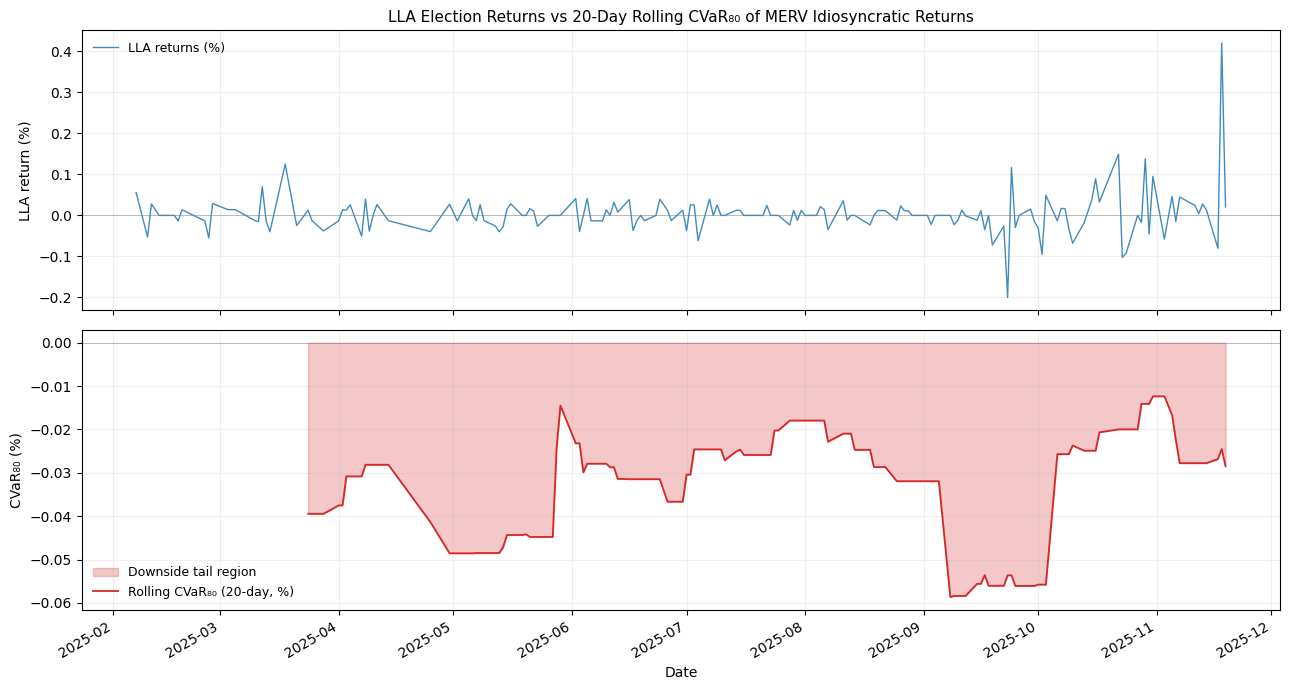


Rolling CVaR₈₀ summary (20-day window, alpha=0.8):


,rolling_cvar_80
count,149.000000
mean,-0.032954
std,0.012539
min,-0.058640
5%,-0.056070
25%,-0.044332
50%,-0.028668
75%,-0.024590
95%,-0.017946
max,-0.012356


Saved: Images/argentina_rolling_cvar.png


In [20]:
# Section 6) Rolling empirical CVaR80 of MERV_idiosyncratic (20-day window)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

_y_col = "MERV_idiosyncratic"
_x_col = "LLA_returns"

if "merged_inner" not in globals():
    raise ValueError("merged_inner is required. Run data preparation cells first.")

_required = [_y_col, _x_col]
_missing = [c for c in _required if c not in merged_inner.columns]
if _missing:
    raise ValueError(f"Missing columns in merged_inner: {_missing}")

roll_df = merged_inner[[_x_col, _y_col]].dropna().copy().reset_index()
# Reset index name can vary (e.g., index/Date/category); standardize to timestamp.
idx_col = roll_df.columns[0]
roll_df = roll_df.rename(columns={idx_col: "timestamp"})
roll_df["timestamp"] = pd.to_datetime(roll_df["timestamp"])
roll_df = roll_df.sort_values("timestamp").reset_index(drop=True)

ROLL_WINDOW = 20
CVAR_ALPHA = 0.80  # 0.95 on 20 days gives only 1 tail obs (floor(20*0.05)=1); 0.80 gives 4

def _empirical_cvar(series, alpha=0.80):
    arr = np.asarray(series, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.nan
    threshold = np.percentile(arr, (1.0 - alpha) * 100.0)
    tail = arr[arr <= threshold]
    return float(np.mean(tail)) if len(tail) > 0 else float(np.min(arr))

rolling_cvar_vals = [np.nan] * (ROLL_WINDOW - 1)
for _i in range(ROLL_WINDOW - 1, len(roll_df)):
    _window = roll_df[_y_col].iloc[_i - ROLL_WINDOW + 1 : _i + 1]
    rolling_cvar_vals.append(_empirical_cvar(_window, alpha=CVAR_ALPHA))

roll_df["rolling_cvar_80"] = rolling_cvar_vals
rolling_cvar_df = roll_df[["timestamp", _y_col, _x_col, "rolling_cvar_80"]].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(roll_df["timestamp"], roll_df[_x_col],
         color="#1f77b4", linewidth=1.0, alpha=0.85, label="LLA returns (%)")
ax1.axhline(0, color="gray", linewidth=0.7, alpha=0.5)
ax1.set_ylabel("LLA return (%)", fontsize=10)
ax1.set_title(
    f"LLA Election Returns vs {ROLL_WINDOW}-Day Rolling CVaR₈₀ of MERV Idiosyncratic Returns",
    fontsize=11
)
ax1.legend(frameon=False, fontsize=9)
ax1.grid(alpha=0.2)

cvar_series = roll_df["rolling_cvar_80"]
ax2.fill_between(roll_df["timestamp"], cvar_series, 0,
                 where=cvar_series < 0, color="#d62728", alpha=0.25, label="Downside tail region")
ax2.plot(roll_df["timestamp"], cvar_series, color="#d62728", linewidth=1.3,
         label=f"Rolling CVaR₈₀ ({ROLL_WINDOW}-day, %)")
ax2.axhline(0, color="gray", linewidth=0.7, alpha=0.5)
ax2.set_ylabel("CVaR₈₀ (%)", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.legend(frameon=False, fontsize=9)
ax2.grid(alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.savefig("Images/argentina_rolling_cvar.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nRolling CVaR₈₀ summary ({ROLL_WINDOW}-day window, alpha={CVAR_ALPHA}):")
display(roll_df["rolling_cvar_80"].dropna().describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("rolling_cvar_80"))
print("Saved: Images/argentina_rolling_cvar.png")

### 7a) Simulation Setup and Forward Paths

Build `sim_df`, fit the production model, run the two-stage branching simulation, and compute `scenario_summary` with bootstrap CVaR₉₅ at each terminal node. Also produces `scenario_summary_by_market` and `terminal_summary_by_market` for the tree visualisation and reporting cells.

## 7) Branching Simulation and Scenario Analysis

Forward scenario generation using the selected model. The branching mechanism applies 25th and 75th percentile shocks to the LLA probability level, propagated through the fitted model over a 5-day horizon. Bootstrap CVaR₉₅ is computed at each terminal node.

## 6) Rolling CVaR of Idiosyncratic Returns

20-day rolling empirical CVaR₉₅ of `MERV_idiosyncratic`, plotted alongside `LLA_returns`. Serves as a time-varying tail-risk diagnostic: compare periods of elevated electoral uncertainty against periods of heavier downside tails in the Argentine equity residual.

### 5c) Out-of-Sample R² Summary

Report the OOS R² for the selected simulation model over the full expanding-window backtest sequence.

In [21]:
# ====================================================
# Binomial tree simulation from T-5 with binary terminal resolution
# Stage 1: two empirically calibrated intermediate probability nodes
# Stage 2: terminal node MUST be resolution at 1 or 0
# Uses best model across Traditional + ML + GARCH + Foundation when available
# ML/Foundation candidates include time_to_expiry in lagged features
# ====================================================

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

try:
    from arch import arch_model
    HAS_ARCH = True
except Exception:
    HAS_ARCH = False

resolution_date = pd.Timestamp("2025-11-19")
lla_col = "LLA (La Libertad Avanza)"
need_cols = [lla_col, "LLA_returns", "MERV_idiosyncratic", "^MERV"]
sim_df = merged_inner[need_cols].dropna().copy()
sim_df.index = pd.to_datetime(sim_df.index, errors="coerce")
sim_df = sim_df[~sim_df.index.isna()].sort_index().copy()
sim_df["time_to_expiry"] = (resolution_date - sim_df.index.to_series()).dt.days.clip(lower=0).astype(float)

if len(sim_df) < 30:
    raise ValueError(f"Need at least 30 aligned observations for simulation; got {len(sim_df)}")

horizon = 5
if len(sim_df) <= horizon:
    raise ValueError("Not enough observations for a 5-day holdout simulation.")

t0_idx = sim_df.index[-(horizon + 1)]
p_t0 = float(np.clip(sim_df.loc[t0_idx, lla_col], 0.0, 1.0))
merv_t0 = float(sim_df.loc[t0_idx, "^MERV"])

print(f"Simulation anchor date (T-5): {pd.Timestamp(t0_idx).date()}")
print(f"LLA level at T-5 (used as probability weight): {p_t0:.4f}")
print(f"MERV level at T-5: {merv_t0:.2f}")
print(f"Forecast horizon: {horizon} observations")

train_all = sim_df.loc[:t0_idx, ["LLA_returns", "MERV_idiosyncratic", "time_to_expiry"]].copy()
if len(train_all) < 20:
    raise ValueError(f"Training sample too short up to T-5: {len(train_all)}")

lla_hist = sim_df.loc[:t0_idx, lla_col].astype(float).clip(0.0, 1.0)
delta_hist = lla_hist.diff().dropna()
if delta_hist.empty:
    raise RuntimeError("Insufficient LLA history to calibrate Stage-1 binomial moves.")

q_down = float(delta_hist.quantile(0.25))
q_up = float(delta_hist.quantile(0.75))
if abs(q_up - q_down) < 1e-10:
    eps = max(1e-4, float(delta_hist.std(ddof=0)) if delta_hist.std(ddof=0) > 0 else 1e-3)
    q_down, q_up = -eps, eps

p_stage1_down = float(np.clip(p_t0 + q_down, 0.0, 1.0))
p_stage1_up = float(np.clip(p_t0 + q_up, 0.0, 1.0))
if abs(p_stage1_up - p_stage1_down) < 1e-10:
    bump = min(0.05, max(1e-3, float(delta_hist.abs().median()) if not delta_hist.empty else 1e-3))
    p_stage1_down = float(np.clip(p_t0 - bump, 0.0, 1.0))
    p_stage1_up = float(np.clip(p_t0 + bump, 0.0, 1.0))

stage1_nodes = {"down": p_stage1_down, "up": p_stage1_up}
stage1_prob = {"down": 0.5, "up": 0.5}

print("\nStage-1 binomial calibration:")
print(f"down node probability level: {p_stage1_down:.4f}")
print(f"up node probability level:   {p_stage1_up:.4f}")

selected_model = "VAR"
selected_window = len(train_all)
selected_spec = {}
selected_oos_r2 = np.nan
if "best_window_model_choice" in globals() and isinstance(best_window_model_choice, dict):
    selected_model = str(best_window_model_choice.get("model", selected_model))
    selected_window = int(best_window_model_choice.get("train_window_days", selected_window))
    selected_spec = best_window_model_choice.get("spec", {}) if isinstance(best_window_model_choice.get("spec", {}), dict) else {}
    selected_oos_r2 = float(best_window_model_choice.get("r2_backtest", np.nan))
elif "best_models_causal" in globals() and isinstance(best_models_causal, dict):
    selected_model = str(best_models_causal.get("selected_model", selected_model))
    if "backtest_metrics_argentina" in globals() and isinstance(backtest_metrics_argentina, pd.DataFrame):
        selected_row = backtest_metrics_argentina.loc[backtest_metrics_argentina["model"].astype(str) == selected_model]
        if not selected_row.empty and "r2_backtest" in selected_row.columns:
            selected_oos_r2 = float(selected_row.iloc[0]["r2_backtest"])

selected_window = max(20, min(selected_window, len(train_all)))
train_sim = train_all.tail(selected_window).copy()

print(f"Simulation model selected: {selected_model}")
print(f"Simulation training window selected: last {selected_window} rows")
print(f"Selected model out-of-sample R2: {selected_oos_r2:.6f}" if np.isfinite(selected_oos_r2) else "Selected model out-of-sample R2: unavailable")


def fit_and_extract_dynamics(train_data, model_name):
    train_core = train_data[["LLA_returns", "MERV_idiosyncratic"]].copy()

    if model_name == "SVAR":
        lag = int(best_models_causal.get("SVAR", {}).get("lag", 1)) if "best_models_causal" in globals() and isinstance(best_models_causal, dict) and best_models_causal.get("SVAR") is not None else 1
        A_template = np.array([[1, 0], ["E", 1]], dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train_core, svar_type="A", A=A_template)
            fit = mod.fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        return coefs, intercept, int(coefs.shape[0])

    if model_name == "VECM":
        coint_rank = 1
        k_ar_diff = 1
        if "best_models_causal" in globals() and isinstance(best_models_causal, dict) and best_models_causal.get("VECM") is not None:
            vecm_spec = best_models_causal["VECM"]
            coint_rank = int(vecm_spec.get("coint_rank", 1))
            k_ar_diff = int(vecm_spec.get("k_ar_diff", 1))
        fit = VECM(train_core, coint_rank=coint_rank, k_ar_diff=k_ar_diff, deterministic="co").fit()
        coefs = np.array(fit.var_rep, dtype=float)
        det_coef = getattr(fit, "det_coef", None)
        if det_coef is not None and np.size(det_coef) > 0:
            intercept = np.array(det_coef, dtype=float)[:, 0]
        else:
            intercept = np.zeros(train_core.shape[1], dtype=float)
        return coefs, intercept, int(coefs.shape[0])

    lag = int(best_models_causal.get("VAR", {}).get("lag", 1)) if "best_models_causal" in globals() and isinstance(best_models_causal, dict) and best_models_causal.get("VAR") is not None else 1
    fit = VAR(train_core).fit(lag)
    coefs = np.array(fit.coefs, dtype=float)
    intercept = np.array(fit.intercept, dtype=float)
    return coefs, intercept, int(coefs.shape[0])


def simulate_with_linear_dynamic(train_data, lla_future_rets, model_name):
    coefs, intercept, k_ar = fit_and_extract_dynamics(train_data, model_name)
    lla_hist_local = train_data["LLA_returns"].astype(float).tolist()
    m_hist_local = train_data["MERV_idiosyncratic"].astype(float).tolist()
    if len(lla_hist_local) < k_ar or len(m_hist_local) < k_ar:
        raise RuntimeError(f"Not enough history for lag order {k_ar}.")

    preds = []
    for step in range(len(lla_future_rets)):
        lla_next = float(lla_future_rets[step])
        m_next = float(intercept[1])
        for lag in range(1, k_ar + 1):
            A_lag = coefs[lag - 1]
            m_next += float(A_lag[1, 0]) * float(lla_hist_local[-lag])
            m_next += float(A_lag[1, 1]) * float(m_hist_local[-lag])
        preds.append(m_next)
        lla_hist_local.append(lla_next)
        m_hist_local.append(m_next)

    return np.array(preds, dtype=float)


def build_lagged_xy(train_slice, n_lags):
    rows = []
    x_vals = train_slice["LLA_returns"].to_numpy(dtype=float)
    y_vals = train_slice["MERV_idiosyncratic"].to_numpy(dtype=float)
    tte_vals = train_slice["time_to_expiry"].to_numpy(dtype=float)
    for t in range(n_lags, len(train_slice)):
        rec = {"target": y_vals[t]}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = x_vals[t - lag]
            rec[f"y_lag{lag}"] = y_vals[t - lag]
            rec[f"tte_lag{lag}"] = tte_vals[t - lag]
        rec["tte_current"] = tte_vals[t]
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feat_cols = [c for c in out.columns if c != "target"]
    return out[feat_cols], out["target"], feat_cols


def derive_tte_future(train_data, steps, tte_future=None):
    if tte_future is not None:
        arr = np.asarray(tte_future, dtype=float)
        if len(arr) != int(steps):
            raise ValueError("tte_future length must match forecast steps.")
        return arr
    if "time_to_expiry" in train_data.columns and len(train_data) > 0:
        start_tte = float(train_data["time_to_expiry"].iloc[-1])
    else:
        start_tte = float(steps)
    return np.maximum(start_tte - np.arange(1, int(steps) + 1, dtype=float), 0.0)


def simulate_with_ml_like(train_data, lla_future_rets, model_name, n_lags=3, params=None, tte_future=None):
    params = {} if params is None else dict(params)
    X_train, y_train, feat_cols = build_lagged_xy(train_data, n_lags)
    if len(X_train) < 25:
        raise RuntimeError("Too few rows for lagged ML training.")

    if model_name == "Ridge":
        est = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=params.get("alpha", 1.0)))])
    elif model_name == "Lasso":
        est = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=params.get("alpha", 0.01), max_iter=20000, random_state=42))])
    elif model_name == "ElasticNet":
        est = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=params.get("alpha", 0.001), l1_ratio=params.get("l1_ratio", 0.5), max_iter=20000, random_state=42))])
    elif model_name == "SVR":
        est = Pipeline([("scaler", StandardScaler()), ("model", SVR(C=params.get("C", 1.0), epsilon=params.get("epsilon", 0.1), gamma=params.get("gamma", "scale"), kernel=params.get("kernel", "rbf")))])
    elif model_name == "RandomForest":
        est = RandomForestRegressor(n_estimators=params.get("n_estimators", 300), max_depth=params.get("max_depth", 5), min_samples_leaf=params.get("min_samples_leaf", 2), random_state=42)
    elif model_name == "ExtraTrees":
        est = ExtraTreesRegressor(n_estimators=params.get("n_estimators", 300), max_depth=params.get("max_depth", 5), min_samples_leaf=params.get("min_samples_leaf", 2), random_state=42)
    elif model_name == "GradientBoosting":
        est = GradientBoostingRegressor(n_estimators=params.get("n_estimators", 300), learning_rate=params.get("learning_rate", 0.03), max_depth=params.get("max_depth", 2), random_state=42)
    elif model_name == "FoundationModel":
        est = GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42)
    else:
        raise ValueError(f"Unsupported ML/Foundation model: {model_name}")

    est.fit(X_train, y_train)
    x_hist = train_data["LLA_returns"].astype(float).tolist()
    y_hist = train_data["MERV_idiosyncratic"].astype(float).tolist()
    tte_hist = train_data["time_to_expiry"].astype(float).tolist()
    tte_path = derive_tte_future(train_data, len(lla_future_rets), tte_future=tte_future)

    preds = []
    for step in range(len(lla_future_rets)):
        row = {}
        for lag in range(1, n_lags + 1):
            row[f"x_lag{lag}"] = float(x_hist[-lag])
            row[f"y_lag{lag}"] = float(y_hist[-lag])
            row[f"tte_lag{lag}"] = float(tte_hist[-lag])
        row["tte_current"] = float(tte_path[step])
        y_next = float(est.predict(pd.DataFrame([row], columns=feat_cols))[0])
        preds.append(y_next)
        x_hist.append(float(lla_future_rets[step]))
        y_hist.append(y_next)
        tte_hist.append(float(tte_path[step]))
    return np.array(preds, dtype=float)


def simulate_with_garch(train_data, lla_future_rets):
    if not HAS_ARCH:
        raise RuntimeError("arch package not available for GARCH model.")
    y_hist = train_data["MERV_idiosyncratic"].astype(float).tolist()
    preds = []
    for _ in lla_future_rets:
        am = arch_model(np.array(y_hist, dtype=float), vol="Garch", p=1, q=1, mean="AR", lags=1)
        fit = am.fit(disp="off")
        y_next = float(fit.forecast(horizon=1).mean.iloc[-1, 0])
        preds.append(y_next)
        y_hist.append(y_next)
    return np.array(preds, dtype=float)


def run_model_for_path(train_data, lla_future_rets):
    if selected_model in ["VAR", "SVAR", "VECM"]:
        return simulate_with_linear_dynamic(train_data, lla_future_rets, selected_model)
    if selected_model == "GARCH":
        return simulate_with_garch(train_data, lla_future_rets)

    n_lags = int(selected_spec.get("n_lags", 3)) if isinstance(selected_spec, dict) else 3
    params = dict(selected_spec.get("params", {})) if isinstance(selected_spec, dict) else {}
    return simulate_with_ml_like(train_data, lla_future_rets, selected_model, n_lags=n_lags, params=params)


def safe_return(next_level, prev_level):
    if prev_level <= 1e-12:
        return 0.0 if next_level <= 1e-12 else 1e6
    return float(next_level / prev_level - 1.0)


scenario_rows = []
path_outputs = {}

for s1_name, p1 in stage1_nodes.items():
    p1_prob = float(stage1_prob[s1_name])
    ret_step1 = safe_return(p1, p_t0)

    for terminal in [1.0, 0.0]:
        ret_terminal = safe_return(terminal, p1)

        lla_path = np.zeros(horizon, dtype=float)
        lla_path[0] = ret_step1
        lla_path[-1] = ret_terminal

        idio_path = run_model_for_path(train_sim, lla_path)
        merv_path = merv_t0 * np.cumprod(1.0 + idio_path)

        cond_prob = float(np.clip(p1, 0.0, 1.0)) if terminal == 1.0 else float(1.0 - np.clip(p1, 0.0, 1.0))
        joint_prob = p1_prob * cond_prob

        node_name = f"{s1_name}->resolve_{int(terminal)}"
        path_outputs[node_name] = {
            "merv_path": merv_path,
            "joint_prob": joint_prob,
            "terminal": int(terminal),
        }

        scenario_rows.append(
            {
                "branch": node_name,
                "stage1": s1_name,
                "stage1_prob_node": p1,
                "probability": joint_prob,
                "terminal_resolution": int(terminal),
                "base_prob_t_minus_5": p_t0,
                "step1_prob_level": p1,
                "horizon_days": horizon,
                "selected_model": selected_model,
                "selected_window_days": selected_window,
                "terminal_abnormal_return": float(merv_path[-1] / merv_t0 - 1.0),
                "max_drawdown": float((merv_path / np.maximum.accumulate(merv_path) - 1.0).min()),
            }
        )

scenario_summary = pd.DataFrame(scenario_rows).sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)
print("\nBinomial path-level summary:")
display(scenario_summary)

terminal_summary = (
    scenario_summary.groupby("terminal_resolution", as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "total_probability": g["probability"].sum(),
                "expected_terminal_abnormal_return": np.average(g["terminal_abnormal_return"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
                "weighted_max_drawdown": np.average(g["max_drawdown"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
            }
        )
    )
    .reset_index(drop=True)
)
terminal_summary["terminal_label"] = terminal_summary["terminal_resolution"].map({1: "Resolves to 1", 0: "Resolves to 0"})
terminal_summary = terminal_summary[["terminal_resolution", "terminal_label", "total_probability", "expected_terminal_abnormal_return", "weighted_max_drawdown"]]

print("Terminal-node summary (only two final nodes):")
display(terminal_summary)

w = scenario_summary["probability"].to_numpy()
r = scenario_summary["terminal_abnormal_return"].to_numpy()
expected_terminal = float(np.sum(w * r))
var95 = float(np.quantile(r, 0.05))
es95 = float(r[r <= var95].mean()) if np.any(r <= var95) else var95

scenario_stats = pd.DataFrame(
    {
        "metric": ["Expected terminal abnormal return", "5% quantile (VaR-like)", "Expected shortfall 95%"],
        "value": [expected_terminal, var95, es95],
    }
)
print("Distribution summary (path-level):")
display(scenario_stats)

prob_check = float(scenario_summary["probability"].sum())
print(f"Total probability across all branches: {prob_check:.6f}")

Simulation anchor date (T-5): 2025-11-12
LLA level at T-5 (used as probability weight): 0.7200
MERV level at T-5: 2984608.00
Forecast horizon: 5 observations

Stage-1 binomial calibration:
down node probability level: 0.7100
up node probability level:   0.7300
Simulation model selected: ElasticNet
Simulation training window selected: last 148 rows
Selected model out-of-sample R2: 0.299694

Binomial path-level summary:


,branch,stage1,stage1_prob_node,probability,terminal_resolution,base_prob_t_minus_5,step1_prob_level,horizon_days,selected_model,selected_window_days,terminal_abnormal_return,max_drawdown
0,down->resolve_0,down,0.71,0.145,0,0.72,0.71,5,ElasticNet,148,0.060459,0.0
1,down->resolve_1,down,0.71,0.355,1,0.72,0.71,5,ElasticNet,148,0.060459,0.0
2,up->resolve_0,up,0.73,0.135,0,0.72,0.73,5,ElasticNet,148,0.061500,0.0
3,up->resolve_1,up,0.73,0.365,1,0.72,0.73,5,ElasticNet,148,0.061500,0.0


Terminal-node summary (only two final nodes):


,terminal_resolution,terminal_label,total_probability,expected_terminal_abnormal_return,weighted_max_drawdown
0,0,Resolves to 0,0.28,0.060961,0.0
1,1,Resolves to 1,0.72,0.060987,0.0


Distribution summary (path-level):


,metric,value
0,Expected terminal abnormal return,0.060980
1,5% quantile (VaR-like),0.060459
2,Expected shortfall 95%,0.060459


Total probability across all branches: 1.000000


In [22]:
# Canonical by-market output schema and bootstrap CVaR augmentation
# Block bootstrap (block length = sqrt(n)) and OOS residuals (80/20) to match Energy notebook methodology.
import numpy as np
import pandas as pd

if "scenario_summary" not in globals() or not isinstance(scenario_summary, pd.DataFrame) or scenario_summary.empty:
    raise ValueError("scenario_summary is required. Run the simulation cell first.")

if "train_sim" not in globals() or "selected_model" not in globals():
    raise ValueError("Simulation prerequisites are missing. Run the simulation cell first.")


def simulate_market_path_bootstrap(train_data, x_future_rets, selected_model_name,
                                    n_bootstrap=500, alpha=0.95, rng_seed=42, n_lags=3):
    """Block-bootstrap residual simulation returning (point_path, cvar_long, cvar_short, boot_arr).

    cvar_long: left-tail CVaR (adverse for long equity exposure)
    cvar_short: right-tail CVaR (adverse for short/hedged exposure)
    """
    from sklearn.base import clone
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge, Lasso, ElasticNet
    from sklearn.svm import SVR
    from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

    x_col, y_col = "LLA_returns", "MERV_idiosyncratic"
    x_hist = train_data[x_col].astype(float).tolist()
    y_hist = train_data[y_col].astype(float).tolist()
    tte_hist = train_data["time_to_expiry"].astype(float).tolist() if "time_to_expiry" in train_data.columns else None

    ml_models = {
        "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))]),
        "Lasso": Pipeline([("scale", StandardScaler()), ("model", Lasso(alpha=0.01, max_iter=20000, random_state=42))]),
        "ElasticNet": Pipeline([("scale", StandardScaler()), ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42))]),
        "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "FoundationModel": GradientBoostingRegressor(n_estimators=150, learning_rate=0.02, max_depth=2, random_state=42),
    }

    if selected_model_name not in ml_models:
        point_path = run_model_for_path(train_data, x_future_rets)
        return point_path, float("nan"), float("nan"), np.array([])

    feat_rows, y_vals = [], []
    for t in range(n_lags, len(train_data)):
        row = {}
        for lag in range(1, n_lags + 1):
            row[f"{x_col}_lag{lag}"] = float(x_hist[t - lag])
            row[f"{y_col}_lag{lag}"] = float(y_hist[t - lag])
        if tte_hist:
            row["time_to_expiry"] = float(tte_hist[t])
        feat_rows.append(row)
        y_vals.append(float(y_hist[t]))
    feat_cols = list(feat_rows[0].keys())
    X_train = pd.DataFrame(feat_rows, columns=feat_cols)
    y_train = pd.Series(y_vals)
    model = clone(ml_models[selected_model_name])
    model.fit(X_train, y_train)

    # OOS residuals (80/20 holdout) — prevents in-sample optimism in tail estimates
    _n_lagged = len(X_train)
    _oos_split = int(_n_lagged * 0.80)
    if _oos_split >= 10 and (_n_lagged - _oos_split) >= 5:
        _oos_model = clone(ml_models[selected_model_name])
        _oos_model.fit(X_train.iloc[:_oos_split], y_train.iloc[:_oos_split])
        _oos_pred = _oos_model.predict(X_train.iloc[_oos_split:])
        residuals = y_train.iloc[_oos_split:].to_numpy() - _oos_pred
    else:
        residuals = y_train.to_numpy() - model.predict(X_train)

    point_path = run_model_for_path(train_data, x_future_rets)

    # Block bootstrap (block length = sqrt(n)) to preserve autocorrelation
    n_steps = len(x_future_rets)
    _blk = max(1, int(len(residuals) ** 0.5))
    _n_blks = int(np.ceil(n_steps / _blk))
    _max_start = max(1, len(residuals) - _blk + 1)

    rng = np.random.default_rng(rng_seed)
    boot_cars = []
    for _ in range(n_bootstrap):
        _starts = rng.integers(0, _max_start, size=_n_blks)
        boot_res = np.concatenate([residuals[s: s + _blk] for s in _starts])[:n_steps]
        x_h, y_h = x_hist.copy(), y_hist.copy()
        y_path_b = []
        for step_i, x_ret in enumerate(x_future_rets):
            row = {}
            x_tmp = x_h + [float(x_ret)]
            for lag in range(1, n_lags + 1):
                row[f"{x_col}_lag{lag}"] = float(x_tmp[-lag])
                row[f"{y_col}_lag{lag}"] = float(y_h[-lag])
            if tte_hist:
                row["time_to_expiry"] = max(0.0, tte_hist[-1] - step_i - 1)
            X_next = pd.DataFrame([row], columns=feat_cols)
            y_next = float(model.predict(X_next)[0]) + float(boot_res[step_i])
            y_path_b.append(y_next)
            x_h.append(float(x_ret))
            y_h.append(y_next)
        boot_cars.append(float(np.sum(y_path_b)) / 100.0)

    boot_arr = np.array(boot_cars, dtype=float)

    # Left-tail CVaR (adverse for long equity exposure / producer)
    threshold_long = np.percentile(boot_arr, (1.0 - alpha) * 100.0)
    tail_long = boot_arr[boot_arr <= threshold_long]
    cvar_long = float(np.mean(tail_long)) if len(tail_long) > 0 else float(np.min(boot_arr))

    # Right-tail CVaR (adverse for short / hedged-consumer exposure)
    threshold_short = np.percentile(boot_arr, alpha * 100.0)
    tail_short = boot_arr[boot_arr >= threshold_short]
    cvar_short = float(np.mean(tail_short)) if len(tail_short) > 0 else float(np.max(boot_arr))

    return point_path, cvar_long, cvar_short, boot_arr


scenario_rows = []
for row in scenario_summary.to_dict(orient="records"):
    node_key = row["branch"]
    terminal = int(row["terminal_resolution"])
    stage1_level = float(row.get("step1_prob_level", row.get("stage1_prob_node", p_t0)))
    lla_future_rets = np.zeros(int(row.get("horizon_days", horizon)), dtype=float)
    lla_future_rets[0] = safe_return(stage1_level, p_t0)
    lla_future_rets[-1] = safe_return(float(terminal), stage1_level)
    _, node_cvar_95_long, node_cvar_95_short, _ = simulate_market_path_bootstrap(
        train_sim, lla_future_rets, selected_model,
        n_bootstrap=500, alpha=0.95, rng_seed=42
    )
    row["node_cvar_95_long"] = node_cvar_95_long
    row["node_cvar_95_short"] = node_cvar_95_short
    scenario_rows.append(row)

scenario_summary = pd.DataFrame(scenario_rows).sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)
scenario_summary_by_market = {"LLA_returns": scenario_summary.copy()}

agg_dict = {
    "probability": ("probability", "sum"),
    "terminal_abnormal_return": ("terminal_abnormal_return", "mean"),
}
if "node_cvar_95_long" in scenario_summary.columns:
    agg_dict["node_cvar_95_long"] = ("node_cvar_95_long", "mean")
if "node_cvar_95_short" in scenario_summary.columns:
    agg_dict["node_cvar_95_short"] = ("node_cvar_95_short", "mean")

terminal_summary = (
    scenario_summary.groupby("terminal_resolution", as_index=False)
    .agg(**agg_dict)
    .sort_values("terminal_resolution")
    .reset_index(drop=True)
)
terminal_summary_by_market = {"LLA_returns": terminal_summary.copy()}

print("Scenario summary and terminal summary refreshed with block-bootstrap CVaR (long + short tails):")
display(scenario_summary)
display(terminal_summary)

Scenario summary and terminal summary refreshed with block-bootstrap CVaR (long + short tails):


,branch,stage1,stage1_prob_node,probability,terminal_resolution,base_prob_t_minus_5,step1_prob_level,horizon_days,selected_model,selected_window_days,terminal_abnormal_return,max_drawdown,node_cvar_95_long,node_cvar_95_short
0,down->resolve_0,down,0.71,0.145,0,0.72,0.71,5,ElasticNet,148,0.060459,0.0,0.001031,0.005854
1,down->resolve_1,down,0.71,0.355,1,0.72,0.71,5,ElasticNet,148,0.060459,0.0,0.000163,0.004986
2,up->resolve_0,up,0.73,0.135,0,0.72,0.73,5,ElasticNet,148,0.061500,0.0,0.001040,0.005863
3,up->resolve_1,up,0.73,0.365,1,0.72,0.73,5,ElasticNet,148,0.061500,0.0,0.000196,0.005018


,terminal_resolution,probability,terminal_abnormal_return,node_cvar_95_long,node_cvar_95_short
0,0,0.28,0.06098,0.001036,0.005858
1,1,0.72,0.06098,0.000179,0.005002


### 7b) Feature Importance and Counterfactual Sensitivity

Rank predictor importances in the fitted simulation model. For SVR, permutation importance is used since no `feature_importances_` attribute is available. Compute a one-step counterfactual sensitivity sweep over `LLA_returns_lag1` to quantify the marginal effect of the election signal on next-period MERV idiosyncratic return forecasts.

In [23]:
# ====================================================
# Training audit: is PM signal being learned and used?
# ====================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path

_audit_required = ["best_window_by_model", "best_window_model_choice", "train_all"]
_missing = [v for v in _audit_required if v not in globals()]
if _missing:
    raise ValueError(
        f"Missing prerequisites: {_missing}. "
        "Run the modeling and simulation cells (Sections 5b and 7a) first."
    )

if not isinstance(best_window_by_model, pd.DataFrame) or best_window_by_model.empty:
    raise ValueError("best_window_by_model is empty; cannot audit training.")

# Pick comparator models
trad_pool = best_window_by_model[best_window_by_model["family"] == "Traditional"].copy()
if trad_pool.empty:
    raise ValueError("No Traditional model available in best_window_by_model.")
trad_row = trad_pool.sort_values(["rmse", "mae"]).iloc[0]
trad_model = str(trad_row["model"])
trad_window = int(trad_row["train_window_days"])
trad_spec = trad_row.get("spec", {}) if isinstance(trad_row.get("spec", {}), dict) else {}

ml_fams = ["ML", "Foundation"]
ml_oos_r2 = np.nan
selected_family = str(best_window_model_choice.get("family", "")) if isinstance(best_window_model_choice, dict) else ""
if selected_family in ml_fams:
    ml_model = str(best_window_model_choice.get("model"))
    ml_window = int(best_window_model_choice.get("train_window_days", len(train_all)))
    ml_spec = best_window_model_choice.get("spec", {}) if isinstance(best_window_model_choice.get("spec", {}), dict) else {}
    ml_oos_r2 = float(best_window_model_choice.get("r2_backtest", np.nan))
else:
    ml_pool = best_window_by_model[best_window_by_model["family"].isin(ml_fams)].copy()
    if ml_pool.empty:
        raise ValueError("No ML/Foundation model available for training audit.")
    ml_row = ml_pool.sort_values(["rmse", "mae"]).iloc[0]
    ml_model = str(ml_row["model"])
    ml_window = int(ml_row["train_window_days"])
    ml_spec = ml_row.get("spec", {}) if isinstance(ml_row.get("spec", {}), dict) else {}
    ml_oos_r2 = float(ml_row.get("r2_backtest", np.nan))

# Build lagged dataset for ML model
ml_window = max(20, min(int(ml_window), len(train_all)))
if not np.isfinite(ml_oos_r2) and "r2_backtest" in best_window_by_model.columns:
    ml_match = best_window_by_model.loc[
        (best_window_by_model["model"].astype(str) == ml_model)
        & (best_window_by_model["train_window_days"].astype(int) == int(ml_window))
    ]
    if not ml_match.empty:
        ml_oos_r2 = float(ml_match.iloc[0]["r2_backtest"])
if not np.isfinite(ml_oos_r2) and "backtest_metrics_argentina" in globals() and isinstance(backtest_metrics_argentina, pd.DataFrame):
    ml_match = backtest_metrics_argentina.loc[backtest_metrics_argentina["model"].astype(str) == ml_model]
    if not ml_match.empty and "r2_backtest" in ml_match.columns:
        ml_oos_r2 = float(ml_match.iloc[0]["r2_backtest"])
ml_train = train_all.tail(ml_window).copy()
ml_n_lags = int(ml_spec.get("n_lags", 3)) if isinstance(ml_spec, dict) else 3
ml_params = dict(ml_spec.get("params", {})) if isinstance(ml_spec, dict) else {}

X_train, y_train, feat_cols = build_lagged_xy(ml_train, ml_n_lags)
if X_train.empty:
    raise RuntimeError("Lagged ML training matrix is empty.")

# Holdout split for permutation importance (80/20) — mirrors Energy notebook methodology
_n_pi = len(X_train)
_pi_split = int(_n_pi * 0.80)
_pi_has_holdout = _pi_split >= 15 and (_n_pi - _pi_split) >= 10

# Fit the exact selected ML estimator
if ml_model == "Ridge":
    est = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=ml_params.get("alpha", 1.0)))])
elif ml_model == "Lasso":
    est = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=ml_params.get("alpha", 0.01), max_iter=20000, random_state=42))])
elif ml_model == "ElasticNet":
    est = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=ml_params.get("alpha", 0.001), l1_ratio=ml_params.get("l1_ratio", 0.5), max_iter=20000, random_state=42))])
elif ml_model == "SVR":
    est = Pipeline([("scaler", StandardScaler()), ("model", SVR(C=ml_params.get("C", 1.0), epsilon=ml_params.get("epsilon", 0.1), gamma=ml_params.get("gamma", "scale"), kernel=ml_params.get("kernel", "rbf")))])
elif ml_model == "RandomForest":
    est = RandomForestRegressor(n_estimators=ml_params.get("n_estimators", 300), max_depth=ml_params.get("max_depth", 5), min_samples_leaf=ml_params.get("min_samples_leaf", 2), random_state=42)
elif ml_model == "ExtraTrees":
    est = ExtraTreesRegressor(n_estimators=ml_params.get("n_estimators", 300), max_depth=ml_params.get("max_depth", 5), min_samples_leaf=ml_params.get("min_samples_leaf", 2), random_state=42)
elif ml_model in ["GradientBoosting", "FoundationModel"]:
    if ml_model == "FoundationModel":
        est = GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42)
    else:
        est = GradientBoostingRegressor(n_estimators=ml_params.get("n_estimators", 300), learning_rate=ml_params.get("learning_rate", 0.03), max_depth=ml_params.get("max_depth", 2), random_state=42)
else:
    raise ValueError(f"Unsupported ML model for audit: {ml_model}")

est.fit(X_train, y_train)
train_r2 = float(est.score(X_train, y_train))

# Feature importance on holdout set when window is large enough
from sklearn.base import clone as _clone_est
if _pi_has_holdout:
    _est_pi = _clone_est(est)
    _est_pi.fit(X_train.iloc[:_pi_split], y_train.iloc[:_pi_split])
    X_pi = X_train.iloc[_pi_split:]
    y_pi = y_train.iloc[_pi_split:]
    _importance_source = "holdout (OOS 20%)"
else:
    _est_pi = est
    X_pi = X_train
    y_pi = y_train
    _importance_source = "in-sample (window too small for holdout)"

# Extract importance / coefficients where possible
importance_rows = []
base_model = _est_pi.named_steps["model"] if hasattr(_est_pi, "named_steps") else _est_pi
if hasattr(base_model, "feature_importances_"):
    imp = np.asarray(base_model.feature_importances_, dtype=float)
    for c, v in zip(feat_cols, imp):
        importance_rows.append({"feature": c, "importance": float(v), "type": "feature_importance"})
elif hasattr(base_model, "coef_"):
    coef = np.asarray(base_model.coef_, dtype=float).ravel()
    for c, v in zip(feat_cols, coef):
        importance_rows.append({"feature": c, "importance": float(v), "type": "coefficient"})

importance_df = pd.DataFrame(importance_rows)
if not importance_df.empty:
    # Normalise raw values to sum to 1 so shares are comparable across cases.
    # For coef-based models (ElasticNet, Ridge) raw abs-coefficients do not
    # sum to 1; for tree-based feature_importances_ they already do, but we
    # normalise uniformly for consistency.
    _raw_abs = importance_df["importance"].abs()
    _total = float(_raw_abs.sum())
    if _total > 0.0:
        importance_df["importance_share"] = (_raw_abs / _total).round(4)
    else:
        importance_df["importance_share"] = 0.0
    # Sort by normalised share descending
    importance_df = importance_df.sort_values("importance_share", ascending=False).reset_index(drop=True)

# Counterfactual one-step sensitivity: vary x_lag1 (latest PM return), hold all y_lags fixed
base_row = X_train.iloc[[-1]].copy()
x1_name = "x_lag1"
if x1_name not in base_row.columns:
    raise RuntimeError("x_lag1 missing from lagged feature matrix.")

x_grid = np.array([-0.30, -0.15, -0.05, 0.0, 0.05, 0.15, 0.30], dtype=float)
cf_rows = []
for xv in x_grid:
    trial = base_row.copy()
    trial.loc[:, x1_name] = float(xv)
    pred = float(est.predict(trial)[0])
    cf_rows.append({"x_lag1_test": float(xv), "predicted_next_idio_ret": pred})
cf_df = pd.DataFrame(cf_rows)
cf_df["delta_vs_x0"] = cf_df["predicted_next_idio_ret"] - float(cf_df.loc[cf_df["x_lag1_test"] == 0.0, "predicted_next_idio_ret"].iloc[0])

# Traditional linear dynamic direct coupling diagnostic
trad_window = max(20, min(int(trad_window), len(train_all)))
trad_train = train_all.tail(trad_window).copy()
if trad_model in ["VAR", "SVAR", "VECM"]:
    coefs, intercept, k_ar = fit_and_extract_dynamics(trad_train, trad_model)
    x_to_y_lag1 = float(coefs[0, 1, 0])
else:
    x_to_y_lag1 = np.nan

summary = pd.DataFrame(
    {
        "metric": [
            "ML model",
            "ML train window",
            "ML lag count",
            "ML in-sample R2",
            "ML out-of-sample R2",
            "Traditional model",
            "Traditional train window",
            "Traditional lag1 coupling A[1,0]",
            "Counterfactual yhat range when x_lag1 in [-30%, +30%]",
        ],
        "value": [
            ml_model,
            ml_window,
            ml_n_lags,
            train_r2,
            ml_oos_r2,
            trad_model,
            trad_window,
            x_to_y_lag1,
            float(cf_df["predicted_next_idio_ret"].max() - cf_df["predicted_next_idio_ret"].min()),
        ],
    }
)

print("Training audit summary:")
display(summary)

print("One-step ML counterfactual sensitivity to PM return shock (x_lag1):")
display(cf_df)

print(f"Feature importance source: {_importance_source}")
if not importance_df.empty:
    print("Top ML features used by fitted model (importance_share normalised to sum 1.0):")
    _disp_cols = ["feature", "importance_share", "type"] if "importance_share" in importance_df.columns else importance_df.columns.tolist()
    display(importance_df[_disp_cols].head(10))
    print(f"  Sum of shown shares: {importance_df['importance_share'].sum():.4f}" if "importance_share" in importance_df.columns else "")
else:
    print("Feature importance/coefficient unavailable for this estimator type.")

Training audit summary:


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,metric,value
0,ML model,ElasticNet
1,ML train window,148
2,ML lag count,3
3,ML in-sample R2,0.062329
4,ML out-of-sample R2,0.299694
5,Traditional model,VECM
6,Traditional train window,144
7,"Traditional lag1 coupling A[1,0]",-0.068838
8,Counterfactual yhat range when x_lag1 in [-30%...,0.036972


One-step ML counterfactual sensitivity to PM return shock (x_lag1):


,x_lag1_test,predicted_next_idio_ret,delta_vs_x0
0,-0.30,0.028467,0.018486
1,-0.15,0.019224,0.009243
2,-0.05,0.013062,0.003081
3,0.00,0.009981,0.000000
4,0.05,0.006901,-0.003081
5,0.15,0.000739,-0.009243
6,0.30,-0.008504,-0.018486


Feature importance source: holdout (OOS 20%)
Top ML features used by fitted model:


,feature,importance,type
4,y_lag2,-0.003712,coefficient
9,tte_current,0.002660,coefficient
3,x_lag2,-0.001608,coefficient
1,y_lag1,0.001056,coefficient
0,x_lag1,-0.000000,coefficient
2,tte_lag1,0.000000,coefficient
5,tte_lag2,0.000000,coefficient
6,x_lag3,0.000000,coefficient
7,y_lag3,-0.000000,coefficient
8,tte_lag3,0.000000,coefficient


### 7c) Branching Tree Visualisation

Plot the two-stage empirical branching tree with CAR and bootstrap CVaR₉₅ projections at each terminal node.

In [24]:
# Monte Carlo/MCMC removed by design.
# This notebook now uses deterministic binomial branching from `scenario_summary`.

if "scenario_summary" not in globals() or not isinstance(scenario_summary, pd.DataFrame) or scenario_summary.empty:
    raise ValueError("scenario_summary is required. Run the binomial simulation cell first.")

print("Monte Carlo section is disabled. Using binomial branch scenarios only.")

mc_merv_idio_results = pd.DataFrame()
mc_merv_idio_summary = pd.DataFrame()

binomial_terminal_summary = (
    scenario_summary.groupby("terminal_resolution", as_index=False)
    .agg(
        total_probability=("probability", "sum"),
        expected_terminal_abnormal_return=("terminal_abnormal_return", "mean"),
        weighted_max_drawdown=("max_drawdown", "mean"),
    )
    .sort_values("terminal_resolution", ascending=False)
    .reset_index(drop=True)
)
display(binomial_terminal_summary)

Monte Carlo section is disabled. Using binomial branch scenarios only.


,terminal_resolution,total_probability,expected_terminal_abnormal_return,weighted_max_drawdown
0,1,0.72,0.06098,0.0
1,0,0.28,0.06098,0.0


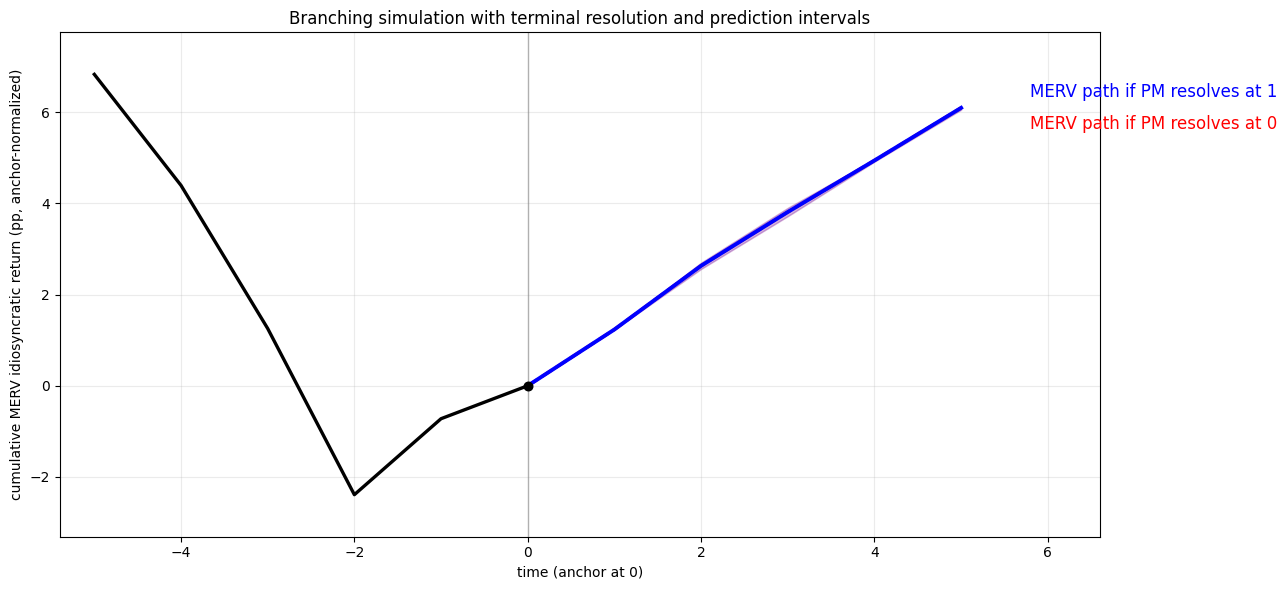

In [25]:
# ====================================================
# Additional visualization: branch-style path with prediction intervals
# Derived from deterministic binomial `path_outputs`
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_vars = ["path_outputs", "sim_df", "t0_idx", "horizon"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing variables from binomial simulation cell: {missing_vars}. "
        "Run the binomial simulation cell first."
    )

hist_idio = sim_df.loc[:t0_idx, "MERV_idiosyncratic"].dropna().astype(float)
if hist_idio.empty:
    raise ValueError("Historical MERV_idiosyncratic series is empty up to anchor.")

pre_hist = min(6, len(hist_idio))
hist_tail = hist_idio.tail(pre_hist).to_numpy() * 100.0
hist_cum = np.cumsum(hist_tail)
hist_rel = hist_cum - hist_cum[-1]
hist_x = np.arange(-len(hist_rel) + 1, 1)

up_nodes = [k for k, v in path_outputs.items() if int(v.get("terminal", 0)) == 1]
dn_nodes = [k for k, v in path_outputs.items() if int(v.get("terminal", 0)) == 0]
if len(up_nodes) == 0 or len(dn_nodes) == 0:
    raise ValueError("Need at least one path in each terminal state to draw branching chart.")

def stack_paths(node_keys):
    arr = []
    for k in node_keys:
        node = path_outputs[k]
        merv_path = np.asarray(node["merv_path"], dtype=float)
        arr.append((merv_path / merv_t0 - 1.0) * 100.0)
    return np.vstack(arr)

up_stack = stack_paths(up_nodes)
dn_stack = stack_paths(dn_nodes)

up_mean = up_stack.mean(axis=0)
up_lo = np.quantile(up_stack, 0.10, axis=0)
up_hi = np.quantile(up_stack, 0.90, axis=0)

dn_mean = dn_stack.mean(axis=0)
dn_lo = np.quantile(dn_stack, 0.10, axis=0)
dn_hi = np.quantile(dn_stack, 0.90, axis=0)

forecast_x = np.arange(0, int(horizon) + 1)
up_mean_plot = np.concatenate(([0.0], up_mean))
up_lo_plot = np.concatenate(([0.0], up_lo))
up_hi_plot = np.concatenate(([0.0], up_hi))
dn_mean_plot = np.concatenate(([0.0], dn_mean))
dn_lo_plot = np.concatenate(([0.0], dn_lo))
dn_hi_plot = np.concatenate(([0.0], dn_hi))

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(hist_x, hist_rel, color="black", lw=2.4, zorder=5)
ax.scatter([0], [0.0], color="black", s=38, zorder=6)

ax.plot(forecast_x, dn_mean_plot, color="red", lw=2.3, ls="--", zorder=2)
ax.fill_between(forecast_x, dn_lo_plot, dn_hi_plot, color="red", alpha=0.16, zorder=1)

ax.plot(forecast_x, up_mean_plot, color="blue", lw=2.8, zorder=4)
ax.fill_between(forecast_x, up_lo_plot, up_hi_plot, color="blue", alpha=0.16, zorder=3)

ax.axvline(0, color="gray", lw=1.0, alpha=0.55)

label_x = forecast_x[-1] + 0.8
up_y = float(up_mean_plot[-1])
dn_y = float(dn_mean_plot[-1])
if abs(up_y - dn_y) < 0.45:
    up_y += 0.35
    dn_y -= 0.35

ax.text(label_x, up_y, "MERV path if PM resolves at 1", color="blue", fontsize=12, va="center")
ax.text(label_x, dn_y, "MERV path if PM resolves at 0", color="red", fontsize=12, va="center")

y_vals = np.concatenate([hist_rel, up_lo_plot, up_hi_plot, dn_lo_plot, dn_hi_plot, np.array([0.0])])
y_pad = max(0.5, 0.10 * (y_vals.max() - y_vals.min() + 1e-9))
ax.set_xlim(hist_x[0] - 0.4, label_x + 0.8)
ax.set_ylim(y_vals.min() - y_pad, y_vals.max() + y_pad)

ax.set_title("Branching simulation with terminal resolution and prediction intervals")
ax.set_xlabel("time (anchor at 0)")
ax.set_ylabel("cumulative MERV idiosyncratic return (pp, anchor-normalized)")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 7d) Scenario Outputs and Sensitivity Analysis

Terminal-node CAR and CVaR₉₅ table, one-step IRF sensitivity comparison between best ML and best Traditional model, multi-horizon sensitivity grid, lag sensitivity audit, and SVAR consistency check.

/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been

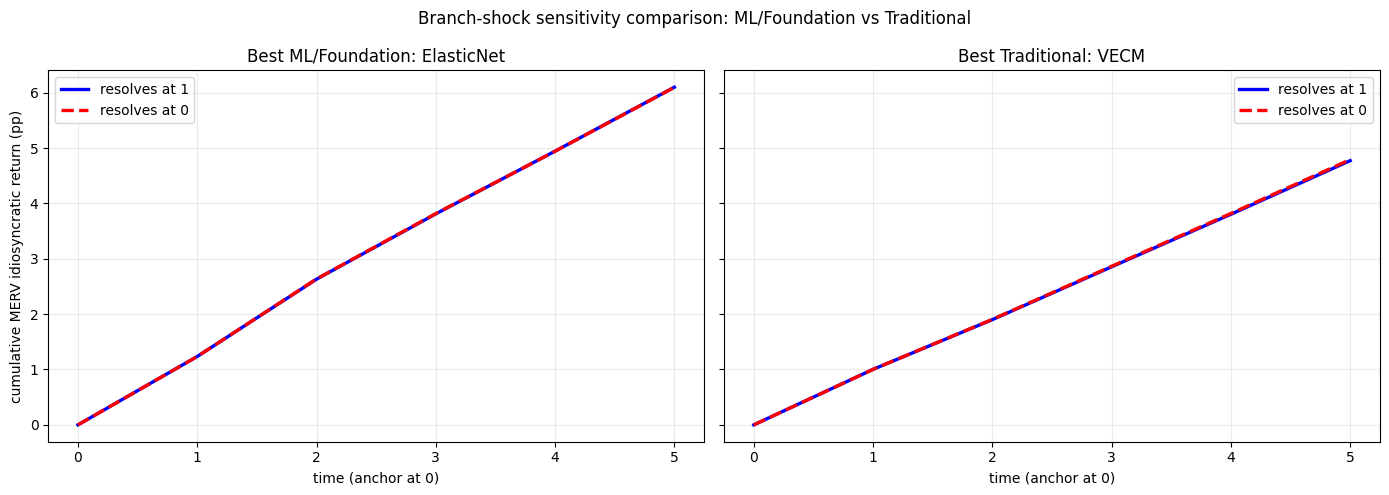

Model sensitivity comparison (terminal differences):


,model,family,window_days,terminal_gap_pp_resolve1_minus_resolve0,resolve1_terminal_pp,resolve0_terminal_pp
0,ElasticNet,ML/Foundation,148,0.002581,6.098690,6.096109
1,VECM,Traditional,144,-0.019256,4.771871,4.791127


In [26]:
# ====================================================
# Sensitivity comparison: best ML vs best Traditional model
# Uses the same Stage-1/Stage-2 PM shock paths for both engines
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["best_window_by_model", "train_all", "stage1_nodes", "stage1_prob", "horizon", "p_t0", "merv_t0"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing prerequisites: {missing}. Run model-selection + simulation cells first.")

if not isinstance(best_window_by_model, pd.DataFrame) or best_window_by_model.empty:
    raise ValueError("best_window_by_model is empty; cannot build model comparison.")

# Pick best Traditional model
trad_pool = best_window_by_model[best_window_by_model["family"] == "Traditional"].copy()
if trad_pool.empty:
    raise ValueError("No Traditional model available in best_window_by_model.")
trad_row = trad_pool.sort_values(["rmse", "mae"]).iloc[0]
trad_model = str(trad_row["model"])
trad_window = int(trad_row["train_window_days"])

# Pick ML-side comparator: selected model if ML/Foundation; otherwise best ML/Foundation model
ml_fams = ["ML", "Foundation"]
selected_family = None
if "best_window_model_choice" in globals() and isinstance(best_window_model_choice, dict):
    selected_family = str(best_window_model_choice.get("family", ""))

if selected_family in ml_fams:
    ml_model = str(best_window_model_choice.get("model"))
    ml_window = int(best_window_model_choice.get("train_window_days", len(train_all)))
    ml_spec = best_window_model_choice.get("spec", {}) if isinstance(best_window_model_choice.get("spec", {}), dict) else {}
else:
    ml_pool = best_window_by_model[best_window_by_model["family"].isin(ml_fams)].copy()
    if ml_pool.empty:
        raise ValueError("No ML/Foundation model available for comparison.")
    ml_row = ml_pool.sort_values(["rmse", "mae"]).iloc[0]
    ml_model = str(ml_row["model"])
    ml_window = int(ml_row["train_window_days"])
    ml_spec = ml_row.get("spec", {}) if isinstance(ml_row.get("spec", {}), dict) else {}

# Pull spec for traditional row if present
trad_spec = trad_row.get("spec", {}) if isinstance(trad_row.get("spec", {}), dict) else {}


def _simulate_model_path(model_name, train_data, lla_future_rets, spec):
    if model_name in ["VAR", "SVAR", "VECM"]:
        return simulate_with_linear_dynamic(train_data, lla_future_rets, model_name)
    if model_name == "GARCH":
        return simulate_with_garch(train_data, lla_future_rets)

    n_lags = int(spec.get("n_lags", 3)) if isinstance(spec, dict) else 3
    params = dict(spec.get("params", {})) if isinstance(spec, dict) else {}
    return simulate_with_ml_like(train_data, lla_future_rets, model_name, n_lags=n_lags, params=params)


def _build_terminal_curves(model_name, train_window, spec):
    train_window = max(20, min(int(train_window), len(train_all)))
    train_data = train_all.tail(train_window).copy()

    by_terminal = {0: [], 1: []}
    for s1_name, p1 in stage1_nodes.items():
        p1_prob = float(stage1_prob[s1_name])
        ret_step1 = safe_return(p1, p_t0)

        for terminal in [1.0, 0.0]:
            ret_terminal = safe_return(terminal, p1)
            lla_path = np.zeros(int(horizon), dtype=float)
            lla_path[0] = ret_step1
            lla_path[-1] = ret_terminal

            idio_path = _simulate_model_path(model_name, train_data, lla_path, spec)
            merv_path = merv_t0 * np.cumprod(1.0 + idio_path)
            curve = np.concatenate(([0.0], (merv_path / merv_t0 - 1.0) * 100.0))

            cond_prob = float(np.clip(p1, 0.0, 1.0)) if terminal == 1.0 else float(1.0 - np.clip(p1, 0.0, 1.0))
            joint_prob = p1_prob * cond_prob
            by_terminal[int(terminal)].append((curve, joint_prob))

    agg = {}
    for term in [0, 1]:
        curves = np.array([c for c, _ in by_terminal[term]], dtype=float)
        probs = np.array([p for _, p in by_terminal[term]], dtype=float)
        probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / len(probs)
        agg[term] = np.average(curves, axis=0, weights=probs)
    return agg


ml_curves = _build_terminal_curves(ml_model, ml_window, ml_spec)
trad_curves = _build_terminal_curves(trad_model, trad_window, trad_spec)

x = np.arange(0, int(horizon) + 1)

ml_gap = float(ml_curves[1][-1] - ml_curves[0][-1])
trad_gap = float(trad_curves[1][-1] - trad_curves[0][-1])

cmp_table = pd.DataFrame(
    {
        "model": [ml_model, trad_model],
        "family": ["ML/Foundation", "Traditional"],
        "window_days": [ml_window, trad_window],
        "terminal_gap_pp_resolve1_minus_resolve0": [ml_gap, trad_gap],
        "resolve1_terminal_pp": [float(ml_curves[1][-1]), float(trad_curves[1][-1])],
        "resolve0_terminal_pp": [float(ml_curves[0][-1]), float(trad_curves[0][-1])],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(x, ml_curves[1], color="blue", lw=2.4, label="resolves at 1")
axes[0].plot(x, ml_curves[0], color="red", lw=2.4, ls="--", label="resolves at 0")
axes[0].set_title(f"Best ML/Foundation: {ml_model}")
axes[0].set_xlabel("time (anchor at 0)")
axes[0].set_ylabel("cumulative MERV idiosyncratic return (pp)")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(x, trad_curves[1], color="blue", lw=2.4, label="resolves at 1")
axes[1].plot(x, trad_curves[0], color="red", lw=2.4, ls="--", label="resolves at 0")
axes[1].set_title(f"Best Traditional: {trad_model}")
axes[1].set_xlabel("time (anchor at 0)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.suptitle("Branch-shock sensitivity comparison: ML/Foundation vs Traditional")
plt.tight_layout()
plt.show()

print("Model sensitivity comparison (terminal differences):")
display(cmp_table)

Sensitivity grid summary (both models):


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been

,family,model,window_days,shock_pp,horizon_days,terminal_gap_pp_resolve1_minus_resolve0,max_path_divergence_pp,mean_path_divergence_pp,resolve1_terminal_pp,resolve0_terminal_pp
0,ML/Foundation,ElasticNet,148,2.0,5,0.010325,0.022790,0.009450,6.100449,6.090125
1,ML/Foundation,ElasticNet,148,2.0,10,0.010985,0.022790,0.009926,12.119732,12.108747
2,ML/Foundation,ElasticNet,148,2.0,20,0.012294,0.022790,0.010770,25.338087,25.325793
3,ML/Foundation,ElasticNet,148,5.0,5,0.064529,0.142435,0.059060,6.112761,6.048231
4,ML/Foundation,ElasticNet,148,5.0,10,0.068656,0.142435,0.062038,12.132852,12.064196
5,ML/Foundation,ElasticNet,148,5.0,20,0.076840,0.142435,0.067314,25.352776,25.275936
6,ML/Foundation,ElasticNet,148,10.0,5,0.258120,0.569739,0.236243,6.156732,5.898612
7,ML/Foundation,ElasticNet,148,10.0,10,0.274626,0.569739,0.248155,12.179709,11.905083
8,ML/Foundation,ElasticNet,148,10.0,20,0.307362,0.569739,0.269258,25.405235,25.097873
9,ML/Foundation,ElasticNet,148,15.0,5,0.580781,1.281912,0.531557,6.230020,5.649239


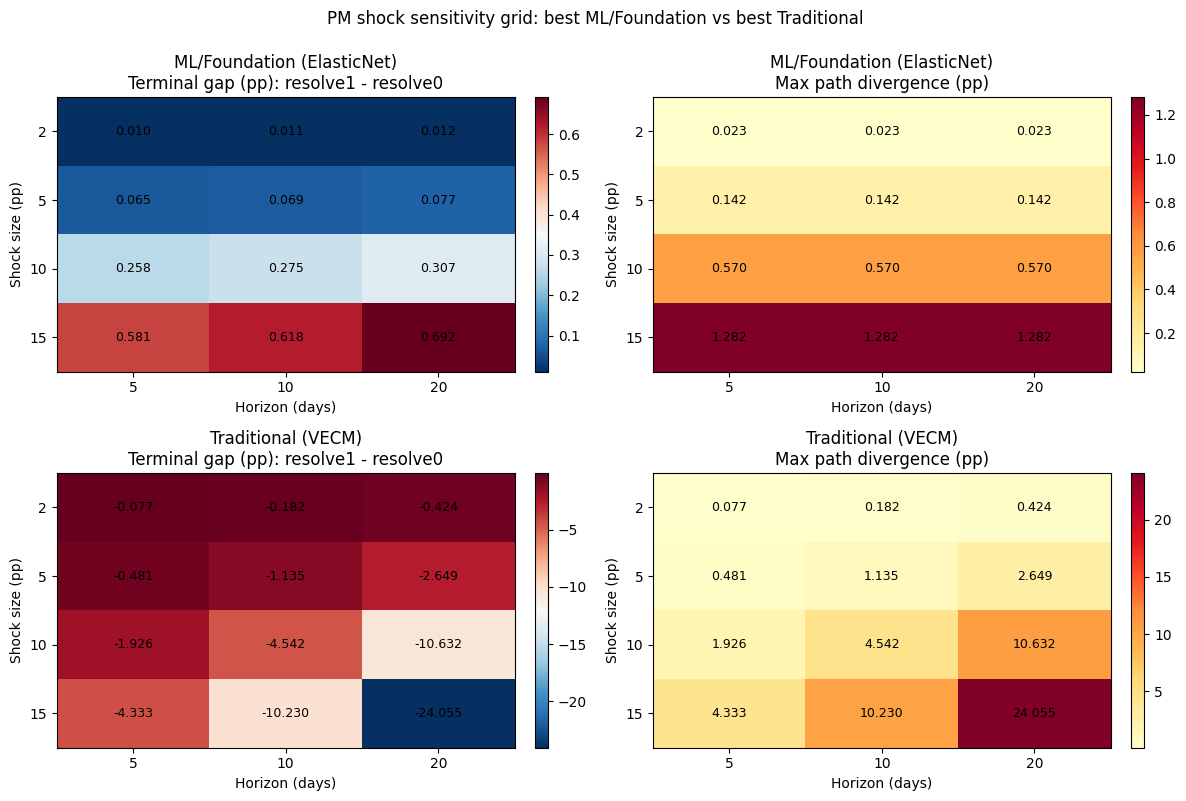

In [27]:
# ====================================================
# Sensitivity grid: best ML/Foundation vs best Traditional
# Grid axes: PM Stage-1 shock size (pp) x forecast horizon (days)
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["best_window_by_model", "best_window_model_choice", "train_all", "p_t0", "merv_t0"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing prerequisites: {missing}. Run model-selection + simulation cells first.")

if not isinstance(best_window_by_model, pd.DataFrame) or best_window_by_model.empty:
    raise ValueError("best_window_by_model is empty; cannot build sensitivity grid.")

# Select best Traditional model
trad_pool = best_window_by_model[best_window_by_model["family"] == "Traditional"].copy()
if trad_pool.empty:
    raise ValueError("No Traditional model available in best_window_by_model.")
trad_row = trad_pool.sort_values(["rmse", "mae"]).iloc[0]
trad_model = str(trad_row["model"])
trad_window = int(trad_row["train_window_days"])
trad_spec = trad_row.get("spec", {}) if isinstance(trad_row.get("spec", {}), dict) else {}

# Select ML-side model (chosen model if ML/Foundation; else best ML/Foundation)
ml_fams = ["ML", "Foundation"]
selected_family = str(best_window_model_choice.get("family", "")) if isinstance(best_window_model_choice, dict) else ""
if selected_family in ml_fams:
    ml_model = str(best_window_model_choice.get("model"))
    ml_window = int(best_window_model_choice.get("train_window_days", len(train_all)))
    ml_spec = best_window_model_choice.get("spec", {}) if isinstance(best_window_model_choice.get("spec", {}), dict) else {}
else:
    ml_pool = best_window_by_model[best_window_by_model["family"].isin(ml_fams)].copy()
    if ml_pool.empty:
        raise ValueError("No ML/Foundation model available in best_window_by_model.")
    ml_row = ml_pool.sort_values(["rmse", "mae"]).iloc[0]
    ml_model = str(ml_row["model"])
    ml_window = int(ml_row["train_window_days"])
    ml_spec = ml_row.get("spec", {}) if isinstance(ml_row.get("spec", {}), dict) else {}


def _simulate_model_path(model_name, train_data, lla_future_rets, spec):
    if model_name in ["VAR", "SVAR", "VECM"]:
        return simulate_with_linear_dynamic(train_data, lla_future_rets, model_name)
    if model_name == "GARCH":
        return simulate_with_garch(train_data, lla_future_rets)
    n_lags = int(spec.get("n_lags", 3)) if isinstance(spec, dict) else 3
    params = dict(spec.get("params", {})) if isinstance(spec, dict) else {}
    return simulate_with_ml_like(train_data, lla_future_rets, model_name, n_lags=n_lags, params=params)


def _terminal_curves_for_grid(model_name, train_window, spec, horizon_days, shock_pp):
    train_window = max(20, min(int(train_window), len(train_all)))
    train_data = train_all.tail(train_window).copy()

    shock = float(shock_pp) / 100.0
    p_down = float(np.clip(p_t0 - shock, 0.0, 1.0))
    p_up = float(np.clip(p_t0 + shock, 0.0, 1.0))
    stage_nodes = {"down": p_down, "up": p_up}
    stage_probs = {"down": 0.5, "up": 0.5}

    by_terminal = {0: [], 1: []}

    for s1_name, p1 in stage_nodes.items():
        p1_prob = float(stage_probs[s1_name])
        ret_step1 = safe_return(p1, p_t0)

        for terminal in [1.0, 0.0]:
            ret_terminal = safe_return(terminal, p1)
            lla_path = np.zeros(int(horizon_days), dtype=float)
            lla_path[0] = ret_step1
            lla_path[-1] = ret_terminal

            idio_path = _simulate_model_path(model_name, train_data, lla_path, spec)
            merv_path = merv_t0 * np.cumprod(1.0 + idio_path)
            curve = np.concatenate(([0.0], (merv_path / merv_t0 - 1.0) * 100.0))

            cond_prob = float(np.clip(p1, 0.0, 1.0)) if terminal == 1.0 else float(1.0 - np.clip(p1, 0.0, 1.0))
            joint_prob = p1_prob * cond_prob
            by_terminal[int(terminal)].append((curve, joint_prob))

    out = {}
    for term in [0, 1]:
        curves = np.array([c for c, _ in by_terminal[term]], dtype=float)
        probs = np.array([p for _, p in by_terminal[term]], dtype=float)
        probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / len(probs)
        out[term] = np.average(curves, axis=0, weights=probs)
    return out


shock_pp_grid = [2, 5, 10, 15]
horizon_grid = [5, 10, 20]

model_configs = [
    {"family": "ML/Foundation", "model": ml_model, "window": ml_window, "spec": ml_spec},
    {"family": "Traditional", "model": trad_model, "window": trad_window, "spec": trad_spec},
]

rows = []
for cfg in model_configs:
    for shock_pp in shock_pp_grid:
        for hz in horizon_grid:
            curves = _terminal_curves_for_grid(
                model_name=cfg["model"],
                train_window=cfg["window"],
                spec=cfg["spec"],
                horizon_days=hz,
                shock_pp=shock_pp,
            )

            gap_terminal = float(curves[1][-1] - curves[0][-1])
            max_div = float(np.max(np.abs(curves[1] - curves[0])))
            mean_div = float(np.mean(np.abs(curves[1] - curves[0])))

            rows.append(
                {
                    "family": cfg["family"],
                    "model": cfg["model"],
                    "window_days": int(cfg["window"]),
                    "shock_pp": float(shock_pp),
                    "horizon_days": int(hz),
                    "terminal_gap_pp_resolve1_minus_resolve0": gap_terminal,
                    "max_path_divergence_pp": max_div,
                    "mean_path_divergence_pp": mean_div,
                    "resolve1_terminal_pp": float(curves[1][-1]),
                    "resolve0_terminal_pp": float(curves[0][-1]),
                }
            )

sensitivity_grid_df = pd.DataFrame(rows).sort_values(["family", "shock_pp", "horizon_days"]).reset_index(drop=True)

print("Sensitivity grid summary (both models):")
display(sensitivity_grid_df)

# Heatmaps by model: terminal gap and max divergence
families_order = ["ML/Foundation", "Traditional"]
metrics = [
    ("terminal_gap_pp_resolve1_minus_resolve0", "Terminal gap (pp): resolve1 - resolve0", "RdBu_r"),
    ("max_path_divergence_pp", "Max path divergence (pp)", "YlOrRd"),
]

fig, axes = plt.subplots(len(families_order), len(metrics), figsize=(12, 8), squeeze=False)
for i, fam in enumerate(families_order):
    fam_df = sensitivity_grid_df[sensitivity_grid_df["family"] == fam].copy()
    model_name = fam_df["model"].iloc[0] if not fam_df.empty else fam

    for j, (metric_col, metric_title, cmap) in enumerate(metrics):
        ax = axes[i, j]
        if fam_df.empty:
            ax.set_visible(False)
            continue

        piv = fam_df.pivot(index="shock_pp", columns="horizon_days", values=metric_col).sort_index().reindex(columns=sorted(horizon_grid))
        data = piv.to_numpy(dtype=float)
        im = ax.imshow(data, aspect="auto", cmap=cmap)

        ax.set_xticks(np.arange(len(piv.columns)))
        ax.set_xticklabels([int(c) for c in piv.columns])
        ax.set_yticks(np.arange(len(piv.index)))
        ax.set_yticklabels([int(r) for r in piv.index])
        ax.set_xlabel("Horizon (days)")
        ax.set_ylabel("Shock size (pp)")
        ax.set_title(f"{fam} ({model_name})\n{metric_title}")

        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                ax.text(c, r, f"{data[r, c]:.3f}", ha="center", va="center", color="black", fontsize=9)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("PM shock sensitivity grid: best ML/Foundation vs best Traditional", y=0.995)
plt.tight_layout()
plt.show()

In [28]:
# ====================================================
# Inversion audit: verify LLA and MERV sign conventions
# ====================================================

import numpy as np
import pandas as pd

lla_col = "LLA (La Libertad Avanza)"
need = ["merged_inner", "best_window_by_model", "train_all", "p_t0"]
missing = [v for v in need if v not in globals()]
if missing:
    raise ValueError(f"Missing prerequisites: {missing}. Run upstream cells first.")

if lla_col not in merged_inner.columns:
    raise ValueError(f"{lla_col} not found in merged_inner.")

# 1) Mechanical check: LLA_returns should equal pct_change(LLA level), not inverted
chk = merged_inner[[lla_col, "LLA_returns", "MERV_returns", "MERV_idiosyncratic"]].dropna().copy()
chk["LLA_returns_rebuilt"] = chk[lla_col].pct_change()
ret_diff_max_abs = float((chk["LLA_returns"] - chk["LLA_returns_rebuilt"]).abs().dropna().max())

# 2) Branch-direction check: up-shock in PM level should produce positive step return
shock_pp_test = 5.0
p_up_test = float(np.clip(p_t0 + shock_pp_test / 100.0, 0.0, 1.0))
p_dn_test = float(np.clip(p_t0 - shock_pp_test / 100.0, 0.0, 1.0))
ret_up_test = float(safe_return(p_up_test, p_t0))
ret_dn_test = float(safe_return(p_dn_test, p_t0))

# 3) Data-level sign checks (not model-imposed): contemporaneous and lead-lag
corr_same_idio = float(chk["LLA_returns"].corr(chk["MERV_idiosyncratic"]))
corr_same_raw = float(chk["LLA_returns"].corr(chk["MERV_returns"]))
corr_lead1_idio = float(chk["LLA_returns"].corr(chk["MERV_idiosyncratic"].shift(-1)))

# Simple OLS slopes via numpy lstsq (with intercept)
X = np.column_stack([np.ones(len(chk)), chk["LLA_returns"].to_numpy(dtype=float)])
y_raw = chk["MERV_returns"].to_numpy(dtype=float)
y_idio = chk["MERV_idiosyncratic"].to_numpy(dtype=float)
beta_raw = np.linalg.lstsq(X, y_raw, rcond=None)[0]
beta_idio = np.linalg.lstsq(X, y_idio, rcond=None)[0]

# 4) VECM/Traditional one-step response check on fitted dynamics
trad_pool = best_window_by_model[best_window_by_model["family"] == "Traditional"].copy()
if trad_pool.empty:
    raise ValueError("No Traditional model in best_window_by_model.")
trad_row = trad_pool.sort_values(["rmse", "mae"]).iloc[0]
trad_model = str(trad_row["model"])
trad_window = max(20, min(int(trad_row["train_window_days"]), len(train_all)))
trad_train = train_all.tail(trad_window).copy()

coefs, intercept, k_ar = fit_and_extract_dynamics(trad_train, trad_model)
lag1_x_to_y = float(coefs[0, 1, 0]) if k_ar >= 1 else np.nan

x_hist = trad_train["LLA_returns"].astype(float).tolist()
y_hist = trad_train["MERV_idiosyncratic"].astype(float).tolist()
if len(x_hist) < k_ar or len(y_hist) < k_ar:
    raise RuntimeError("Not enough history for one-step sign audit.")


def one_step_linear_from_hist(x_hist_local, y_hist_local, coefs_local, intercept_local, k):
    y_next = float(intercept_local[1])
    for lag in range(1, k + 1):
        A_lag = coefs_local[lag - 1]
        y_next += float(A_lag[1, 0]) * float(x_hist_local[-lag])
        y_next += float(A_lag[1, 1]) * float(y_hist_local[-lag])
    return float(y_next)

base_pred = one_step_linear_from_hist(x_hist, y_hist, coefs, intercept, k_ar)
vecm_cf_rows = []
for dx in [-0.20, -0.10, -0.05, 0.00, 0.05, 0.10, 0.20]:
    x_mod = list(x_hist)
    x_mod[-1] = float(x_mod[-1] + dx)
    pred = one_step_linear_from_hist(x_mod, y_hist, coefs, intercept, k_ar)
    vecm_cf_rows.append({"delta_x_lag1": float(dx), "one_step_yhat": pred, "delta_vs_base": float(pred - base_pred)})

vecm_cf_df = pd.DataFrame(vecm_cf_rows)

summary = pd.DataFrame(
    {
        "check": [
            "LLA_returns equals pct_change(LLA level)",
            "PM up-shock gives positive LLA return",
            "PM down-shock gives negative LLA return",
            "Traditional model used in audit",
            "Traditional lag1 x->y coefficient A[1,0]",
            "Corr same-day: LLA_returns vs MERV_returns",
            "Corr same-day: LLA_returns vs MERV_idiosyncratic",
            "Corr lead1: LLA_returns vs next-day MERV_idiosyncratic",
            "OLS slope: MERV_returns ~ LLA_returns",
            "OLS slope: MERV_idiosyncratic ~ LLA_returns",
        ],
        "value": [
            ret_diff_max_abs,
            ret_up_test,
            ret_dn_test,
            trad_model,
            lag1_x_to_y,
            corr_same_raw,
            corr_same_idio,
            corr_lead1_idio,
            float(beta_raw[1]),
            float(beta_idio[1]),
        ],
    }
)

print("Inversion audit summary (interpretation: no mechanical inversion if first three checks look correct).")
display(summary)

print("Traditional one-step counterfactual response around latest x_lag1 (delta_x_lag1):")
display(vecm_cf_df)

print("Quick read:")
print(f"- max abs diff between stored LLA_returns and rebuilt pct_change: {ret_diff_max_abs:.3e}")
print(f"- up-shock return: {ret_up_test:.6f} | down-shock return: {ret_dn_test:.6f}")
print("- If VECM/Traditional response is negative, that reflects learned dynamics, not an inverted input column.")

Inversion audit summary (interpretation: no mechanical inversion if first three checks look correct).


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,check,value
0,LLA_returns equals pct_change(LLA level),0.0
1,PM up-shock gives positive LLA return,0.069444
2,PM down-shock gives negative LLA return,-0.069444
3,Traditional model used in audit,VECM
4,"Traditional lag1 x->y coefficient A[1,0]",-0.068838
5,Corr same-day: LLA_returns vs MERV_returns,0.000037
6,Corr same-day: LLA_returns vs MERV_idiosyncratic,0.039996
7,Corr lead1: LLA_returns vs next-day MERV_idios...,-0.06557
8,OLS slope: MERV_returns ~ LLA_returns,0.000025
9,OLS slope: MERV_idiosyncratic ~ LLA_returns,0.026166


Traditional one-step counterfactual response around latest x_lag1 (delta_x_lag1):


,delta_x_lag1,one_step_yhat,delta_vs_base
0,-0.20,0.023794,0.013768
1,-0.10,0.016910,0.006884
2,-0.05,0.013468,0.003442
3,0.00,0.010026,0.000000
4,0.05,0.006585,-0.003442
5,0.10,0.003143,-0.006884
6,0.20,-0.003741,-0.013768


Quick read:
- max abs diff between stored LLA_returns and rebuilt pct_change: 0.000e+00
- up-shock return: 0.069444 | down-shock return: -0.069444
- If VECM/Traditional response is negative, that reflects learned dynamics, not an inverted input column.


Lag sensitivity audit table:


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,lag,traditional_model,traditional_dy_dx_local,traditional_delta_y_if_xlag_plus5pp,traditional_delta_y_if_xlag_minus5pp,ml_model,ml_dy_dx_local_fd,ml_delta_y_if_xlag_plus5pp,ml_delta_y_if_xlag_minus5pp
0,1,VECM,-0.068838,-0.003442,0.003442,ElasticNet,-0.061620,-0.003081,0.003081
1,2,VECM,-0.023573,-0.001179,0.001179,ElasticNet,-0.010341,-0.000517,0.000517
2,3,VECM,NaN,NaN,NaN,ElasticNet,0.102981,0.005149,-0.005149


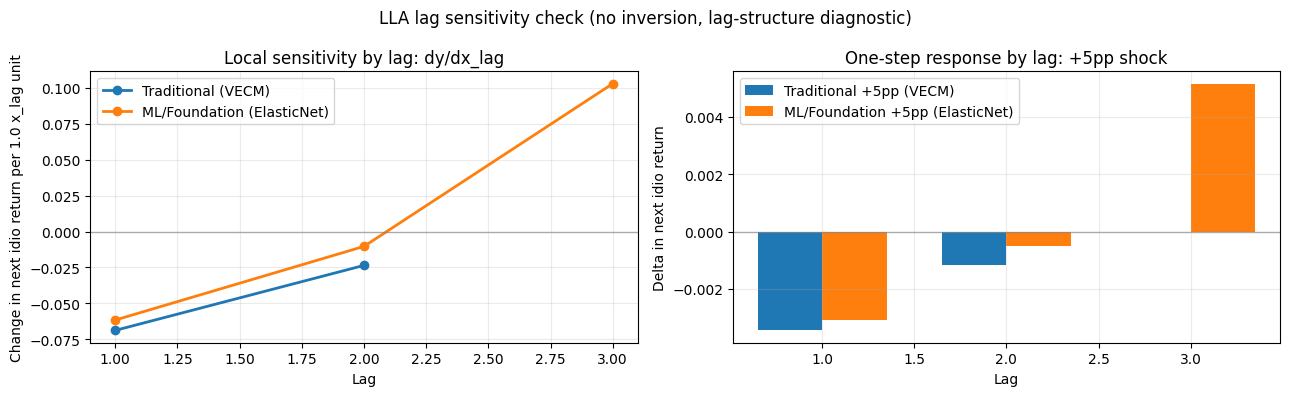

Sanity note: a negative value at a specific lag means that lag enters negatively in the fitted local dynamics.


In [29]:
# ====================================================
# Lag sensitivity audit: per-lag effect of LLA_returns shocks
# Compares best ML/Foundation model vs best Traditional model
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["best_window_by_model", "best_window_model_choice", "train_all"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing prerequisites: {missing}. Run model-selection + simulation cells first.")

if not isinstance(best_window_by_model, pd.DataFrame) or best_window_by_model.empty:
    raise ValueError("best_window_by_model is empty; cannot run lag sensitivity audit.")

# Choose models
trad_pool = best_window_by_model[best_window_by_model["family"] == "Traditional"].copy()
if trad_pool.empty:
    raise ValueError("No Traditional model available in best_window_by_model.")
trad_row = trad_pool.sort_values(["rmse", "mae"]).iloc[0]
trad_model = str(trad_row["model"])
trad_window = int(trad_row["train_window_days"])

ml_fams = ["ML", "Foundation"]
selected_family = str(best_window_model_choice.get("family", "")) if isinstance(best_window_model_choice, dict) else ""
if selected_family in ml_fams:
    ml_model = str(best_window_model_choice.get("model"))
    ml_window = int(best_window_model_choice.get("train_window_days", len(train_all)))
    ml_spec = best_window_model_choice.get("spec", {}) if isinstance(best_window_model_choice.get("spec", {}), dict) else {}
else:
    ml_pool = best_window_by_model[best_window_by_model["family"].isin(ml_fams)].copy()
    if ml_pool.empty:
        raise ValueError("No ML/Foundation model available in best_window_by_model.")
    ml_row = ml_pool.sort_values(["rmse", "mae"]).iloc[0]
    ml_model = str(ml_row["model"])
    ml_window = int(ml_row["train_window_days"])
    ml_spec = ml_row.get("spec", {}) if isinstance(ml_row.get("spec", {}), dict) else {}

# ---- Traditional lag sensitivity (linear dynamics) ----
trad_window = max(20, min(int(trad_window), len(train_all)))
trad_train = train_all.tail(trad_window).copy()
coefs, intercept, k_ar = fit_and_extract_dynamics(trad_train, trad_model)

x_hist = trad_train["LLA_returns"].astype(float).tolist()
y_hist = trad_train["MERV_idiosyncratic"].astype(float).tolist()
if len(x_hist) < k_ar or len(y_hist) < k_ar:
    raise RuntimeError(f"Not enough history for traditional lag order {k_ar}.")


def _one_step_linear(x_hist_local, y_hist_local, coefs_local, intercept_local, k):
    y_next = float(intercept_local[1])
    for lag in range(1, k + 1):
        A_lag = coefs_local[lag - 1]
        y_next += float(A_lag[1, 0]) * float(x_hist_local[-lag])
        y_next += float(A_lag[1, 1]) * float(y_hist_local[-lag])
    return float(y_next)

trad_base = _one_step_linear(x_hist, y_hist, coefs, intercept, k_ar)

# ---- ML lag sensitivity (finite difference around latest state) ----
ml_window = max(20, min(int(ml_window), len(train_all)))
ml_train = train_all.tail(ml_window).copy()
ml_n_lags = int(ml_spec.get("n_lags", 3)) if isinstance(ml_spec, dict) else 3
ml_params = dict(ml_spec.get("params", {})) if isinstance(ml_spec, dict) else {}

X_train, y_train, feat_cols = build_lagged_xy(ml_train, ml_n_lags)
if X_train.empty:
    raise RuntimeError("Lagged ML training matrix is empty.")

if ml_model == "Ridge":
    ml_est = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=ml_params.get("alpha", 1.0)))])
elif ml_model == "Lasso":
    ml_est = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=ml_params.get("alpha", 0.01), max_iter=20000, random_state=42))])
elif ml_model == "ElasticNet":
    ml_est = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=ml_params.get("alpha", 0.001), l1_ratio=ml_params.get("l1_ratio", 0.5), max_iter=20000, random_state=42))])
elif ml_model == "SVR":
    ml_est = Pipeline([("scaler", StandardScaler()), ("model", SVR(C=ml_params.get("C", 1.0), epsilon=ml_params.get("epsilon", 0.1), gamma=ml_params.get("gamma", "scale"), kernel=ml_params.get("kernel", "rbf")))])
elif ml_model == "RandomForest":
    ml_est = RandomForestRegressor(n_estimators=ml_params.get("n_estimators", 300), max_depth=ml_params.get("max_depth", 5), min_samples_leaf=ml_params.get("min_samples_leaf", 2), random_state=42)
elif ml_model == "ExtraTrees":
    ml_est = ExtraTreesRegressor(n_estimators=ml_params.get("n_estimators", 300), max_depth=ml_params.get("max_depth", 5), min_samples_leaf=ml_params.get("min_samples_leaf", 2), random_state=42)
elif ml_model in ["GradientBoosting", "FoundationModel"]:
    if ml_model == "FoundationModel":
        ml_est = GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42)
    else:
        ml_est = GradientBoostingRegressor(n_estimators=ml_params.get("n_estimators", 300), learning_rate=ml_params.get("learning_rate", 0.03), max_depth=ml_params.get("max_depth", 2), random_state=42)
else:
    raise ValueError(f"Unsupported ML model for lag audit: {ml_model}")

ml_est.fit(X_train, y_train)
ml_base_row = X_train.iloc[[-1]].copy()
ml_base_pred = float(ml_est.predict(ml_base_row)[0])

# ---- Per-lag perturbation test ----
small_eps = 0.01   # 1pp for local derivative
big_eps = 0.05     # 5pp for scenario perturbation
max_lag_to_test = max(int(k_ar), int(ml_n_lags))

rows = []
for lag in range(1, max_lag_to_test + 1):
    # Traditional: exact linear sensitivity if lag exists
    if lag <= int(k_ar):
        trad_coef = float(coefs[lag - 1, 1, 0])
        x_plus = list(x_hist)
        x_minus = list(x_hist)
        x_plus[-lag] += big_eps
        x_minus[-lag] -= big_eps
        trad_plus = _one_step_linear(x_plus, y_hist, coefs, intercept, k_ar)
        trad_minus = _one_step_linear(x_minus, y_hist, coefs, intercept, k_ar)
        trad_delta_plus = float(trad_plus - trad_base)
        trad_delta_minus = float(trad_minus - trad_base)
    else:
        trad_coef = np.nan
        trad_delta_plus = np.nan
        trad_delta_minus = np.nan

    # ML: finite-difference local derivative and +-5pp response if lag feature exists
    x_lag_col = f"x_lag{lag}"
    if x_lag_col in ml_base_row.columns:
        ml_plus_small = ml_base_row.copy()
        ml_minus_small = ml_base_row.copy()
        ml_plus_small.loc[:, x_lag_col] = float(ml_plus_small.iloc[0][x_lag_col] + small_eps)
        ml_minus_small.loc[:, x_lag_col] = float(ml_minus_small.iloc[0][x_lag_col] - small_eps)
        ml_pred_plus_small = float(ml_est.predict(ml_plus_small)[0])
        ml_pred_minus_small = float(ml_est.predict(ml_minus_small)[0])
        ml_fd_derivative = float((ml_pred_plus_small - ml_pred_minus_small) / (2.0 * small_eps))

        ml_plus_big = ml_base_row.copy()
        ml_minus_big = ml_base_row.copy()
        ml_plus_big.loc[:, x_lag_col] = float(ml_plus_big.iloc[0][x_lag_col] + big_eps)
        ml_minus_big.loc[:, x_lag_col] = float(ml_minus_big.iloc[0][x_lag_col] - big_eps)
        ml_pred_plus_big = float(ml_est.predict(ml_plus_big)[0])
        ml_pred_minus_big = float(ml_est.predict(ml_minus_big)[0])
        ml_delta_plus = float(ml_pred_plus_big - ml_base_pred)
        ml_delta_minus = float(ml_pred_minus_big - ml_base_pred)
    else:
        ml_fd_derivative = np.nan
        ml_delta_plus = np.nan
        ml_delta_minus = np.nan

    rows.append(
        {
            "lag": int(lag),
            "traditional_model": trad_model,
            "traditional_dy_dx_local": trad_coef,
            "traditional_delta_y_if_xlag_plus5pp": trad_delta_plus,
            "traditional_delta_y_if_xlag_minus5pp": trad_delta_minus,
            "ml_model": ml_model,
            "ml_dy_dx_local_fd": ml_fd_derivative,
            "ml_delta_y_if_xlag_plus5pp": ml_delta_plus,
            "ml_delta_y_if_xlag_minus5pp": ml_delta_minus,
        }
    )

lag_sensitivity_df = pd.DataFrame(rows)
print("Lag sensitivity audit table:")
display(lag_sensitivity_df)

# ---- Visualization: local derivatives and +5pp responses ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_axis = lag_sensitivity_df["lag"].to_numpy(dtype=int)
axes[0].plot(x_axis, lag_sensitivity_df["traditional_dy_dx_local"], marker="o", lw=2.0, label=f"Traditional ({trad_model})")
axes[0].plot(x_axis, lag_sensitivity_df["ml_dy_dx_local_fd"], marker="o", lw=2.0, label=f"ML/Foundation ({ml_model})")
axes[0].axhline(0.0, color="gray", lw=1.0, alpha=0.6)
axes[0].set_title("Local sensitivity by lag: dy/dx_lag")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Change in next idio return per 1.0 x_lag unit")
axes[0].grid(alpha=0.25)
axes[0].legend()

bar_w = 0.35
axes[1].bar(x_axis - bar_w / 2, lag_sensitivity_df["traditional_delta_y_if_xlag_plus5pp"], width=bar_w, label=f"Traditional +5pp ({trad_model})")
axes[1].bar(x_axis + bar_w / 2, lag_sensitivity_df["ml_delta_y_if_xlag_plus5pp"], width=bar_w, label=f"ML/Foundation +5pp ({ml_model})")
axes[1].axhline(0.0, color="gray", lw=1.0, alpha=0.6)
axes[1].set_title("One-step response by lag: +5pp shock")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Delta in next idio return")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.suptitle("LLA lag sensitivity check (no inversion, lag-structure diagnostic)")
plt.tight_layout()
plt.show()

print("Sanity note: a negative value at a specific lag means that lag enters negatively in the fitted local dynamics.")

In [30]:
# ====================================================
# Proposal-aligned hedge sizing with positive-branch handling
# Consumes scenario_summary from the binomial simulation cell
# ====================================================

portfolio_value = 1_000_000
risk_budget_fraction = 0.015
execution_haircut = 0.70
hedge_efficiency = 0.60  # conservative payoff efficiency after costs/slippage

# Exposure convention:
# - long_price: falling MERV is adverse (equity holder view — this is the standard Argentine case)
# - short_price: rising MERV is adverse (short-seller or hedged producer view)
exposure_to_price = "long_price"

if 'scenario_summary' not in globals() or scenario_summary.empty:
    raise ValueError("scenario_summary is missing or empty. Run the binomial simulation cell first.")

w = scenario_summary["probability"].to_numpy(dtype=float)
r_s = scenario_summary["terminal_abnormal_return"].to_numpy(dtype=float)

if exposure_to_price == "long_price":
    L_s = np.maximum(-r_s, 0.0)   # loss when MERV falls
elif exposure_to_price == "short_price":
    L_s = np.maximum(r_s, 0.0)    # loss when MERV rises
else:
    raise ValueError("exposure_to_price must be 'long_price' or 'short_price'.")

weighted_loss = float(np.sum(w * L_s))

# Hedge only the loss in excess of the risk budget
if weighted_loss <= risk_budget_fraction:
    target_coverage = 0.0
else:
    target_coverage = (weighted_loss - risk_budget_fraction) / weighted_loss

raw_hedge_notional_pct = target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
hedge_notional_pct = float(np.clip(raw_hedge_notional_pct * execution_haircut, 0.0, 0.80))
hedge_notional_eur = hedge_notional_pct * portfolio_value

def hedge_instrument_mix(terminal_ret: float) -> str:
    if terminal_ret >= 0:
        return "No downside hedge needed; maintain upside participation (optionally light collar to fund carry)."
    if terminal_ret > -0.02:
        return "Light hedge: MERV put spread (OTM, 1-3m), staged execution (TWAP-style)."
    if terminal_ret > -0.05:
        return "Medium hedge: protective put or collar on MERV; optional small QQQ put sleeve."
    return "Strong hedge: collar + partial de-risking MERV; larger Nasdaq downside sleeve (QQQ puts / PSQ)."

hedge_table = scenario_summary.copy()
hedge_table["recommended_hedge_structure"] = hedge_table["terminal_abnormal_return"].apply(hedge_instrument_mix)
hedge_table["suggested_hedge_notional_pct_of_MERV"] = hedge_notional_pct
hedge_table["suggested_hedge_notional_eur"] = hedge_notional_eur

# Keep compatibility with prior/alternate scenario schemas.
if "year_shift" not in hedge_table.columns:
    hedge_table["year_shift"] = np.nan
if "stage1" not in hedge_table.columns:
    hedge_table["stage1"] = hedge_table["branch"].astype(str).str.lower().map({
        "advanced agi": "advanced",
        "central": "central",
        "delayed agi": "severe_delay",
    }).fillna("unknown")
if "horizon_days" not in hedge_table.columns:
    hedge_table["horizon_days"] = np.nan

display_cols = [
    "branch",
    "stage1",
    "probability",
    "year_shift",
    "horizon_days",
    "terminal_abnormal_return",
    "max_drawdown",
    "recommended_hedge_structure",
    "suggested_hedge_notional_pct_of_MERV",
    "suggested_hedge_notional_eur",
]
display(hedge_table[display_cols])

hedge_policy = pd.DataFrame({
    "parameter": [
        "portfolio_value",
        "risk_budget_fraction",
        "execution_haircut",
        "hedge_efficiency",
        "weighted_loss",
        "target_coverage",
        "final_hedge_notional_pct",
        "final_hedge_notional_eur",
    ],
    "value": [
        portfolio_value,
        risk_budget_fraction,
        execution_haircut,
        hedge_efficiency,
        weighted_loss,
        target_coverage,
        hedge_notional_pct,
        hedge_notional_eur,
    ],
})
display(hedge_policy)

# ============================================================
# CVaR-informed hedge sizing (bootstrap tail risk)
# ============================================================
if "node_cvar_95_long" in hedge_table.columns and hedge_table["node_cvar_95_long"].notna().any():
    cvar_vals = hedge_table["node_cvar_95_long"].to_numpy(dtype=float)
    w_cvar = hedge_table["probability"].to_numpy(dtype=float)

    if exposure_to_price == "long_price":
        cvar_loss = np.maximum(-cvar_vals, 0.0)
    else:
        cvar_loss = np.maximum(-cvar_vals, 0.0)

    weighted_cvar_loss = float(np.sum(w_cvar * cvar_loss))

    if weighted_cvar_loss <= risk_budget_fraction:
        cvar_target_coverage = 0.0
    else:
        cvar_target_coverage = (weighted_cvar_loss - risk_budget_fraction) / weighted_cvar_loss

    raw_cvar_notional_pct = cvar_target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
    cvar_notional_pct = float(np.clip(raw_cvar_notional_pct * execution_haircut, 0.0, 0.80))
    cvar_notional_eur = cvar_notional_pct * portfolio_value

    cvar_hedge_summary = pd.DataFrame([{
        "Metric": "Weighted loss",
        "Point-estimate (CAR)": f"{weighted_loss:.4f}",
        "CVaR₉₅ (bootstrap)": f"{weighted_cvar_loss:.4f}",
    }, {
        "Metric": "Target coverage",
        "Point-estimate (CAR)": f"{target_coverage:.4f}",
        "CVaR₉₅ (bootstrap)": f"{cvar_target_coverage:.4f}",
    }, {
        "Metric": "Hedge notional (% exposure)",
        "Point-estimate (CAR)": f"{hedge_notional_pct:.4f}",
        "CVaR₉₅ (bootstrap)": f"{cvar_notional_pct:.4f}",
    }, {
        "Metric": "Hedge notional (EUR)",
        "Point-estimate (CAR)": f"\u20ac{hedge_notional_eur:,.0f}",
        "CVaR₉₅ (bootstrap)": f"\u20ac{cvar_notional_eur:,.0f}",
    }])

    print("\nHedge sizing comparison: point-estimate vs CVaR₉₅ (bootstrap)")
    display(cvar_hedge_summary)
else:
    print("\n[CVaR hedge sizing skipped: node_cvar_95 not in hedge_table. Run simulation cell first.]")

print("Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.")

,branch,stage1,probability,year_shift,horizon_days,terminal_abnormal_return,max_drawdown,recommended_hedge_structure,suggested_hedge_notional_pct_of_MERV,suggested_hedge_notional_eur
0,down->resolve_0,down,0.145,NaN,5,0.060459,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
1,down->resolve_1,down,0.355,NaN,5,0.060459,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
2,up->resolve_0,up,0.135,NaN,5,0.061500,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
3,up->resolve_1,up,0.365,NaN,5,0.061500,0.0,No downside hedge needed; maintain upside part...,0.0,0.0


,parameter,value
0,portfolio_value,1000000.000
1,risk_budget_fraction,0.015
2,execution_haircut,0.700
3,hedge_efficiency,0.600
4,weighted_loss,0.000
5,target_coverage,0.000
6,final_hedge_notional_pct,0.000
7,final_hedge_notional_eur,0.000



Hedge sizing comparison: point-estimate vs CVaR₉₅ (bootstrap)


,Metric,Point-estimate (CAR),CVaR₉₅ (bootstrap)
0,Weighted loss,0.0000,0.0000
1,Target coverage,0.0000,0.0000
2,Hedge notional (% exposure),0.0000,0.0000
3,Hedge notional (EUR),€0,€0


Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.
